# `econ_anlys_etl.ipynb` — Extract, Transform, and Load (ETL)

> **File:** `econ_anlys_etl.ipynb`
> **Purpose:** Extract, transform, and load all financial, epidemiological, and energy sector data required by the downstream analysis notebooks.
> **Programmer:** Nicholas J. George  |  **Initial Development:** 04/06/2026

---

## Overview

This notebook is the data foundation of a multi-part project examining the economic impact of the COVID-19 pandemic on major asset classes during the period January 22, 2020 – September 14, 2022. It acquires raw data across six financial asset classes, one epidemiological dataset, and one energy sector company dataset; applies a consistent set of transformations to each; and persists the results as JSON files consumed by the downstream analysis notebooks.

Every financial asset class follows a uniform five-step pattern — **Extract → Transform → Display → Correlate → Load** — applied to both absolute prices and daily percentage changes. COVID-19 data follows the same pattern with both raw and cumulative variants. Oil & Gas company data follows a dedicated extract-transform-load flow sourced directly from the SEC and Yahoo Finance.

---

## Dependencies

| Library | Role |
|---|---|
| `assetx` | Data acquisition — financial prices, COVID-19 data, SEC symbols, and company metadata |
| `dtypesx` | Percentage change calculations, date index conversion, and type utilities |
| `logx` | Logging, program lifecycle management, and formatted console output |
| `matplotlibx` | Stacked multi-panel time-series line charts |
| `pandasx` | Formatted table display and Spearman/Pearson correlation matrices |
| `pandas` / `numpy` | Core data structures and numerical operations |

---

## Data Sources and Sections

| Sections | Asset Class | Series |
|---|---|---|
| 1–2 | **Agricultural Prices** | Cocoa, Coffee, Corn, Oats, Orange Juice, Rice, Soybeans, Sugar, Wheat, Live Cattle |
| 3–4 | **Exchange Rates (USD)** | EUR, AUD, CAD, SGD, Bitcoin |
| 5–6 | **Interest Rates** | Treasury Bond, 5-Year, 10-Year, 30-Year Treasury Futures, CBOE 10-Year Yield |
| 7–8 | **Metals Prices** | Gold, Silver, Platinum, Palladium, Copper |
| 9–10 | **Petroleum Prices** | Brent Crude Oil, WTI Crude, RBOB Gasoline, Heating Oil, Natural Gas |
| 11–12 | **Stock Market Indices** | S&P 500, DJIA, NASDAQ, NYSE, Russell 2000 |
| 13–14 | **COVID-19 Data (USA)** | Daily cases, daily deaths, daily combined (cases + deaths), and cumulative variants of each |
| 15 | **Oil & Gas Energy Sector** | SEC-sourced stock symbols and company metadata including market cap statistics, geographic coordinates, and industry classification |

---

## Outputs

The notebook produces **11 JSON files** consumed by the downstream analysis notebooks:

| Config Key | Contents |
|---|---|
| `agr1`, `agr2` | Agricultural prices — split across two files due to column count |
| `exchg_rts` | Exchange rates (USD) — absolute prices |
| `intrt_rts` | Interest rate futures and yields — absolute prices |
| `metals` | Metals prices — absolute prices |
| `petrol` | Petroleum prices — absolute prices |
| `stk_mkt` | Stock market index prices — absolute prices |
| `covid_usa` | U.S. COVID-19 data — daily and cumulative cases, deaths, and combined |
| `all_stcks` | All SEC stock symbols |
| `sctr_stcks` | Filtered Oil & Gas sector symbols |
| `cmps_data` | Oil & Gas company metadata |

---

## ETL Process

### Financial Asset Classes (Sections 1–12)

Each paired section (odd = absolute prices, even = percentage changes) follows five uniform steps:

**1. Extract** — Individual price series are retrieved via `assetx.rtn_cmdt_prices(category, symbol)` using category keys `'agriculture'`, `'currencies'`, `'yields'`, `'metals'`, `'petroleum'`, and `'indices'`.

**2. Transform** — Series are assembled into a pandas DataFrame and aligned via `.dropna()` to enforce a common date index across all series in the asset class. For percentage-change sections, each series is additionally transformed via `dtypesx.cnv_to_pct_chg()` before assembly.

**3. Display** — Each DataFrame is rendered as a formatted sample table via `pandasx.rtn_fmt_tbl()` with currency or percentage formatting applied per column.

**4. Correlate** — A Spearman correlation matrix is computed and displayed for each asset class, for both the absolute-price and percentage-change DataFrames.

**5. Load** — Each DataFrame is serialized to JSON via `pandas.DataFrame.to_json()` using paths defined in `assetx.config_dict['file']` and `mode='w'` to overwrite on each run. Agricultural prices are split across two files (`agr1`, `agr2`) due to column count.

### COVID-19 Data (Sections 13–14)

Section 13 extracts U.S. COVID-19 data via `assetx.rtn_covid_cntry_file_df()`, aligning the date index to the S&P 500 series to ensure temporal consistency with the financial data. The dataset includes six series: daily cases (`covid_cases`), daily deaths (`covid_deaths`), daily combined (`covid_c&d`), and cumulative variants of each (`cml_covid_cases`, `cml_covid_deaths`, `cml_covid_c&d`). Pearson correlation is used in place of Spearman for the COVID data given its count-based integer structure. Section 14 computes percentage changes for all six series and applies the same display, correlation, and load steps.

### Oil & Gas Energy Sector (Section 15)

Section 15 follows a three-step sub-pipeline:

**15.1** — All SEC stock symbols are retrieved and counted via `assetx.rtn_all_symbols_file_array()`.

**15.2** — Symbols are filtered to the Oil & Gas energy sector via `assetx.rtn_sector_symbols_file_array()` using a search configuration file, and the filtered array is persisted.

**15.3–15.4** — Company metadata is retrieved for all sector symbols via `assetx.rtn_cmps_info_file_df()`, including market cap statistics (min, max, mean, median, std, sem), geographic coordinates (latitude, longitude), and industry classification. The result is displayed as a formatted table and serialized to JSON.

---

In [1]:
 #*******************************************************************************************
 #
 #  File Name:  econ_anlys_etl.ipynb
 #
 #  File Description:
 #      This interactive Python notebook econ_anlys_etl.ipynb extracts, transfers, and 
 #      loads economic indicators, covid-19 data, and oil energy sector data for analysis.
 #      
 #
 #  Date            Description                             Programmer
 #  ----------      ------------------------------------    ------------------
 #  04/06/2026      Initial Development                     Nicholas J. George
 #
 #******************************************************************************************/

import assetx
import dtypesx
import logx
import matplotlibx
import pandasx

import numpy as np
import pandas as pd

pd.options.mode.chained_assignment = None

In [2]:
CONSTANT_LOCAL_FILE_NAME = 'econ_anlys_etl.ipynb'

In [3]:
logx.set_log_mode(False)

logx.set_image_mode(False)


logx.begin_program('econ_anlys_etl')

## <br> **Section 1: Agricultural Prices**

### **1.1: Extract Agricultural Prices**

In [4]:
cocoa_pcs_series  = assetx.rtn_cmdt_prices('agriculture', 'cocoa')

logx.log_write_obj(cocoa_pcs_series)

In [5]:
coffee_pcs_series = assetx.rtn_cmdt_prices('agriculture', 'coffee')

logx.log_write_obj(coffee_pcs_series)

In [6]:
corn_pcs_series   = assetx.rtn_cmdt_prices('agriculture', 'corn')

logx.log_write_obj(corn_pcs_series)

In [7]:
oats_pcs_series   = assetx.rtn_cmdt_prices('agriculture', 'oats')

logx.log_write_obj(oats_pcs_series)

In [8]:
orj_pcs_series    = assetx.rtn_cmdt_prices('agriculture', 'orange_juice')

logx.log_write_obj(orj_pcs_series)

In [9]:
rice_pcs_series   = assetx.rtn_cmdt_prices('agriculture', 'rice')

logx.log_write_obj(rice_pcs_series)

In [10]:
sb_pcs_series     = assetx.rtn_cmdt_prices('agriculture', 'soybeans')

logx.log_write_obj(sb_pcs_series)

In [11]:
sug_pcs_series    = assetx.rtn_cmdt_prices('agriculture', 'sugar')

logx.log_write_obj(sug_pcs_series)

In [12]:
wht_pcs_series    = assetx.rtn_cmdt_prices('agriculture', 'wheat')

logx.log_write_obj(wht_pcs_series)

In [13]:
lc_pcs_series     = assetx.rtn_cmdt_prices('agriculture', 'live_cattle')

logx.log_write_obj(lc_pcs_series)

### **1.2: Transform Agricultural Prices**

In [14]:
ttl_dict \
    = {'cocoa':        cocoa_pcs_series,
       'coffee':       coffee_pcs_series,
       'corn':         corn_pcs_series,
       'oats':         oats_pcs_series,
       'orange_juice': orj_pcs_series,
       'rice':         rice_pcs_series,
       'soybeans':     sb_pcs_series,
       'sugar':        sug_pcs_series,
       'wheat':        wht_pcs_series,
       'live_cattle':  lc_pcs_series}

agr_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(agr_df)

In [15]:
title = 'Table 1.2: Agriculture Prices'

fmt_dict \
    = {'cocoa':        pandasx.fmt_dict['curr_flt'],
       'coffee':       pandasx.fmt_dict['curr_flt'],
       'corn':         pandasx.fmt_dict['curr_flt'],
       'oats':         pandasx.fmt_dict['curr_flt'],
       'orange_juice': pandasx.fmt_dict['curr_flt'],
       'rice':         pandasx.fmt_dict['curr_flt'],
       'soybeans':     pandasx.fmt_dict['curr_flt'],
       'sugar':        pandasx.fmt_dict['curr_flt'],
       'wheat':        pandasx.fmt_dict['curr_flt'],
       'live_cattle':  pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(agr_df, title, hide_idx_bool = False).format(fmt_dict)

,cocoa,coffee,corn,oats,orange_juice,rice,soybeans,sugar,wheat,live_cattle
2020-01-22,"$2,803.00",$111.00,$388.75,$313.25,$96.30,"$1,343.50",$913.75,$14.66,$492.50,$126.18
2020-01-23,"$2,771.00",$112.60,$393.75,$316.50,$94.95,"$1,362.50",$909.50,$14.57,$492.25,$124.68
2020-01-24,"$2,733.00",$110.15,$387.25,$303.25,$95.75,"$1,358.50",$902.00,$14.39,$486.00,$124.85
2020-01-27,"$2,734.00",$106.60,$380.50,$300.50,$95.35,"$1,347.00",$897.25,$14.21,$486.50,$122.25
2020-01-28,"$2,703.00",$105.05,$386.50,$307.00,$96.35,"$1,358.50",$895.00,$14.54,$482.00,$122.15
2020-01-29,"$2,727.00",$102.05,$384.25,$307.75,$97.10,"$1,366.50",$893.00,$14.49,$472.00,$121.75
2020-01-30,"$2,801.00",$101.50,$379.50,$305.50,$95.45,"$1,356.00",$876.25,$14.59,$471.00,$121.78
2020-01-31,"$2,777.00",$102.65,$381.25,$303.75,$95.95,"$1,361.00",$872.50,$14.61,$465.50,$121.38
2020-02-03,"$2,734.00",$97.90,$378.75,$300.25,$94.60,"$1,356.50",$877.00,$14.89,$466.75,$121.68
2020-02-04,"$2,757.00",$98.15,$382.25,$308.00,$93.50,"$1,358.50",$879.50,$14.71,$467.25,$121.62


### **1.3: Correlation (Spearman): Agriculture Prices**

In [16]:
title = 'Table 1.3: Correlation (Spearman): Agriculture Prices'

pandasx.rtn_fmt_tbl(agr_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,cocoa,coffee,corn,oats,orange_juice,rice,soybeans,sugar,wheat,live_cattle
cocoa,1.00,0.09,-0.02,0.10,-0.09,-0.20,-0.01,0.23,0.05,0.15
coffee,0.09,1.00,0.82,0.87,0.72,0.46,0.77,0.84,0.91,0.90
corn,-0.02,0.82,1.00,0.79,0.59,0.41,0.94,0.77,0.89,0.82
oats,0.10,0.87,0.79,1.00,0.69,0.52,0.72,0.90,0.90,0.86
orange_juice,-0.09,0.72,0.59,0.69,1.00,0.59,0.60,0.64,0.74,0.68
rice,-0.20,0.46,0.41,0.52,0.59,1.00,0.35,0.34,0.54,0.48
soybeans,-0.01,0.77,0.94,0.72,0.60,0.35,1.00,0.70,0.85,0.77
sugar,0.23,0.84,0.77,0.90,0.64,0.34,0.70,1.00,0.88,0.84
wheat,0.05,0.91,0.89,0.90,0.74,0.54,0.85,0.88,1.00,0.89
live_cattle,0.15,0.90,0.82,0.86,0.68,0.48,0.77,0.84,0.89,1.00


### **1.4: Display Agriculture Prices**

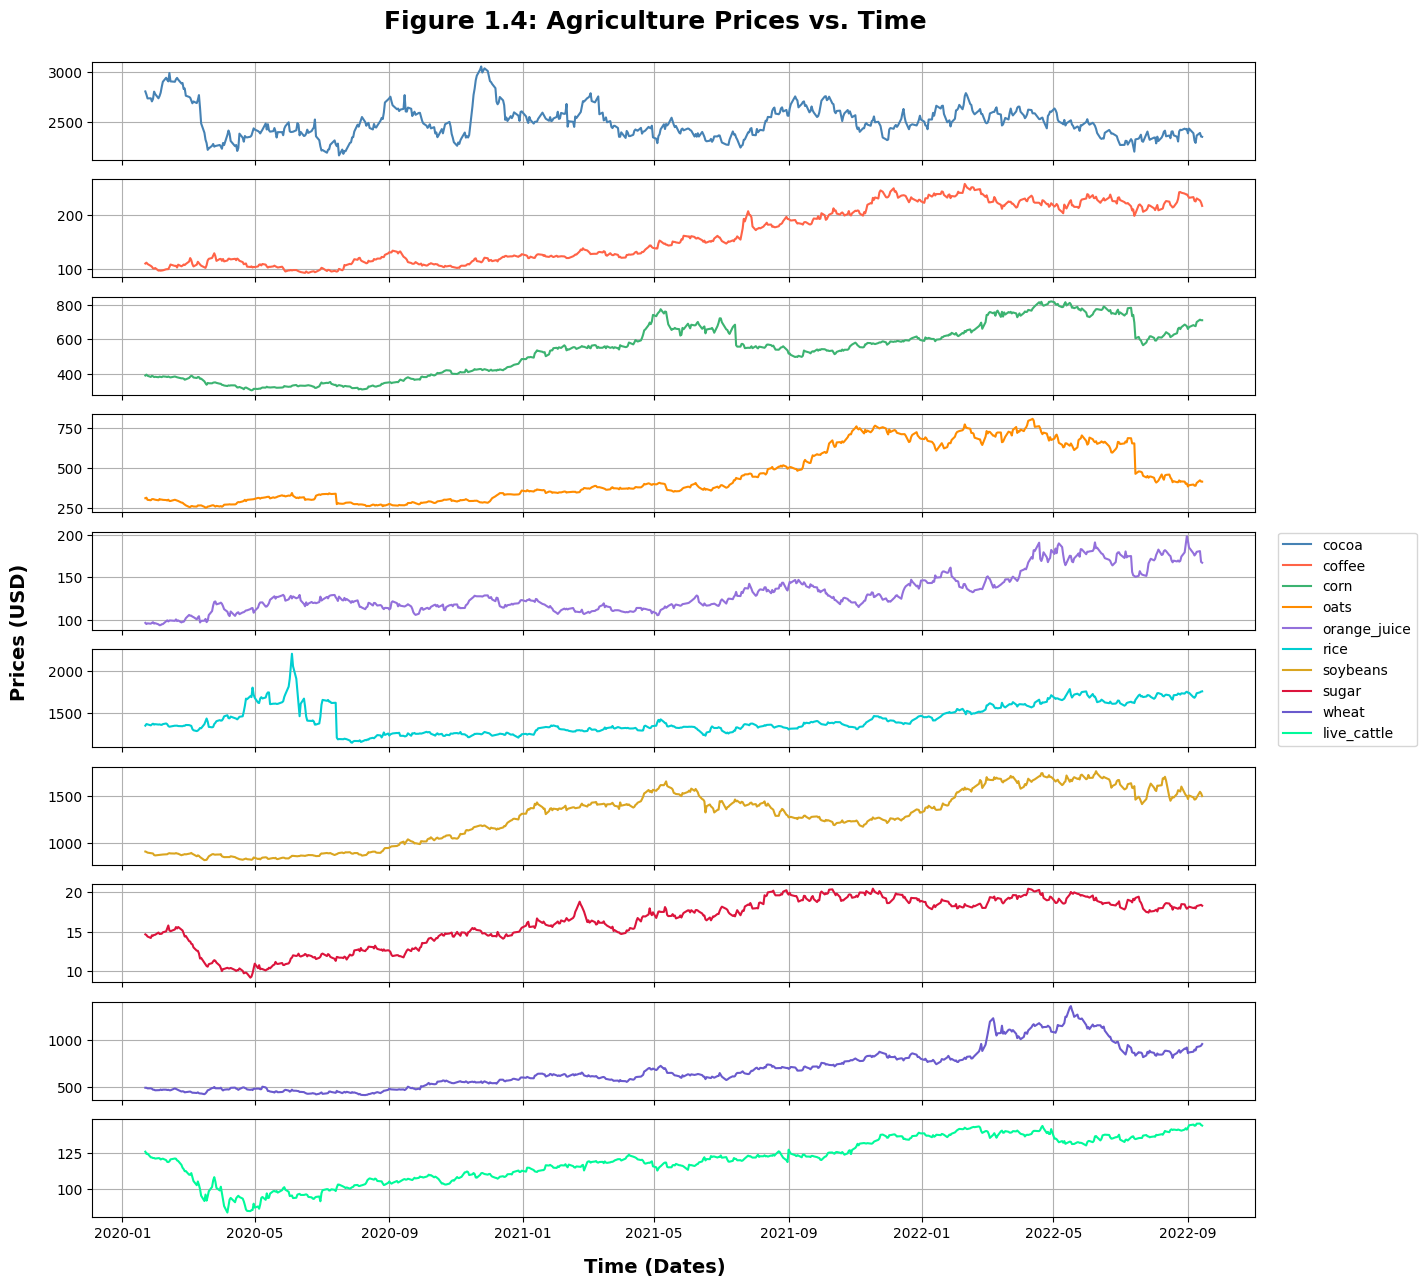

In [17]:
title = 'Figure 1.4: Agriculture Prices vs. Time'


matplotlibx.setup_stacked_line_charts(len(agr_df.columns) * 5)

matplotlibx.set_line_chart_legend_bbox_to_anchor(1.145, 5.9)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (USD)')

matplotlibx.set_line_multichart_fig_dims(15.0, 15.0)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.915)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.07)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(agr_df, title)

### **1.5: Load Agriculture Prices**

In [18]:
hlf_int = len(agr_df.columns) // 2

agr_df.iloc[:, :hlf_int].to_json(assetx.config_dict['file']['agr1'], mode = 'w')

agr_df.iloc[:, hlf_int:].to_json(assetx.config_dict['file']['agr2'], mode = 'w')

## <br> **Section 2: Agricultural Prices (%)**

### **2.1: Calculate Agricultural Prices (%)**

In [19]:
cocoa_pcs_pct_series = dtypesx.cnv_to_pct_chg(cocoa_pcs_series)

logx.log_write_obj(cocoa_pcs_pct_series)

In [20]:
cofy_pcs_pct_series  = dtypesx.cnv_to_pct_chg(coffee_pcs_series)

logx.log_write_obj(cofy_pcs_pct_series)

In [21]:
corn_pcs_pct_series  = dtypesx.cnv_to_pct_chg(corn_pcs_series)

logx.log_write_obj(corn_pcs_pct_series)

In [22]:
oats_pcs_pct_series  = dtypesx.cnv_to_pct_chg(oats_pcs_series)

logx.log_write_obj(oats_pcs_pct_series)

In [23]:
orj_pcs_pct_series   = dtypesx.cnv_to_pct_chg(orj_pcs_series)

logx.log_write_obj(orj_pcs_pct_series)

In [24]:
rice_pcs_pct_series  = dtypesx.cnv_to_pct_chg(rice_pcs_series)

logx.log_write_obj(rice_pcs_pct_series)

In [25]:
sb_pcs_pct_series    = dtypesx.cnv_to_pct_chg(sb_pcs_series)

logx.log_write_obj(sb_pcs_pct_series)

In [26]:
sug_pcs_pct_series   = dtypesx.cnv_to_pct_chg(sug_pcs_series)

logx.log_write_obj(sug_pcs_pct_series)

In [27]:
wht_pcs_pct_series   = dtypesx.cnv_to_pct_chg(wht_pcs_series)

logx.log_write_obj(wht_pcs_pct_series)

In [28]:
lc_pcs_pct_series    = dtypesx.cnv_to_pct_chg(lc_pcs_series)

logx.log_write_obj(lc_pcs_pct_series)

### **2.2: Transform Agricultural Prices (%)**

In [29]:
ttl_dict \
    = {'cocoa%':        cocoa_pcs_pct_series,
       'coffee%':       cofy_pcs_pct_series,
       'corn%':         corn_pcs_pct_series,
       'oats%':         oats_pcs_pct_series,
       'orange_juice%': orj_pcs_pct_series,
       'rice%':         rice_pcs_pct_series,
       'soybeans%':     sb_pcs_pct_series,
       'sugar%':        sug_pcs_pct_series,
       'wheat%':        wht_pcs_pct_series,
       'live_cattle%':  lc_pcs_pct_series}

agr_pct_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(agr_pct_df)

In [30]:
title = 'Table 2.2: Agriculture Prices (%)'

fmt_dict \
    = {'cocoa%':        pandasx.fmt_dict['pct_flt'],
       'coffee%':       pandasx.fmt_dict['pct_flt'],
       'corn%':         pandasx.fmt_dict['pct_flt'],
       'oats%':         pandasx.fmt_dict['pct_flt'],
       'orange_juice%': pandasx.fmt_dict['pct_flt'],
       'rice%':         pandasx.fmt_dict['pct_flt'],
       'soybeans%':     pandasx.fmt_dict['pct_flt'],
       'sugar%':        pandasx.fmt_dict['pct_flt'],
       'wheat%':        pandasx.fmt_dict['pct_flt'],
       'live_cattle%':  pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(agr_pct_df, title, hide_idx_bool = False).format(fmt_dict)

,cocoa%,coffee%,corn%,oats%,orange_juice%,rice%,soybeans%,sugar%,wheat%,live_cattle%
2020-01-23,-1.14%,1.44%,1.29%,1.04%,-1.40%,1.41%,-0.47%,-0.61%,-0.05%,-1.19%
2020-01-24,-1.37%,-2.18%,-1.65%,-4.19%,0.84%,-0.29%,-0.82%,-1.24%,-1.27%,0.14%
2020-01-27,0.04%,-3.22%,-1.74%,-0.91%,-0.42%,-0.85%,-0.53%,-1.25%,0.10%,-2.08%
2020-01-28,-1.13%,-1.45%,1.58%,2.16%,1.05%,0.85%,-0.25%,2.32%,-0.92%,-0.08%
2020-01-29,0.89%,-2.86%,-0.58%,0.24%,0.78%,0.59%,-0.22%,-0.34%,-2.07%,-0.33%
2020-01-30,2.71%,-0.54%,-1.24%,-0.73%,-1.70%,-0.77%,-1.88%,0.69%,-0.21%,0.02%
2020-01-31,-0.86%,1.13%,0.46%,-0.57%,0.52%,0.37%,-0.43%,0.14%,-1.17%,-0.33%
2020-02-03,-1.55%,-4.63%,-0.66%,-1.15%,-1.41%,-0.33%,0.52%,1.92%,0.27%,0.25%
2020-02-04,0.84%,0.26%,0.92%,2.58%,-1.16%,0.15%,0.29%,-1.21%,0.11%,-0.05%
2020-02-05,1.20%,-0.41%,-0.39%,-1.14%,0.27%,-0.33%,0.06%,0.14%,1.39%,-0.72%


### **2.3: Correlation (Spearman): Agriculture Prices (%)**

In [31]:
title = 'Table 2.3: Correlation (Spearman): Agriculture Prices (%)'

pandasx.rtn_fmt_tbl(agr_pct_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,cocoa%,coffee%,corn%,oats%,orange_juice%,rice%,soybeans%,sugar%,wheat%,live_cattle%
cocoa%,1.00,0.15,-0.00,0.05,-0.02,-0.02,0.05,0.10,0.01,0.07
coffee%,0.15,1.00,0.21,0.17,0.14,0.08,0.21,0.22,0.20,0.11
corn%,-0.00,0.21,1.00,0.34,0.08,0.21,0.57,0.28,0.53,0.07
oats%,0.05,0.17,0.34,1.00,0.06,0.14,0.31,0.23,0.32,0.08
orange_juice%,-0.02,0.14,0.08,0.06,1.00,0.05,0.17,0.12,0.08,0.10
rice%,-0.02,0.08,0.21,0.14,0.05,1.00,0.17,0.11,0.23,-0.03
soybeans%,0.05,0.21,0.57,0.31,0.17,0.17,1.00,0.25,0.39,0.10
sugar%,0.10,0.22,0.28,0.23,0.12,0.11,0.25,1.00,0.25,0.07
wheat%,0.01,0.20,0.53,0.32,0.08,0.23,0.39,0.25,1.00,0.06
live_cattle%,0.07,0.11,0.07,0.08,0.10,-0.03,0.10,0.07,0.06,1.00


### **2.4: Display Agricultural Prices (%)**

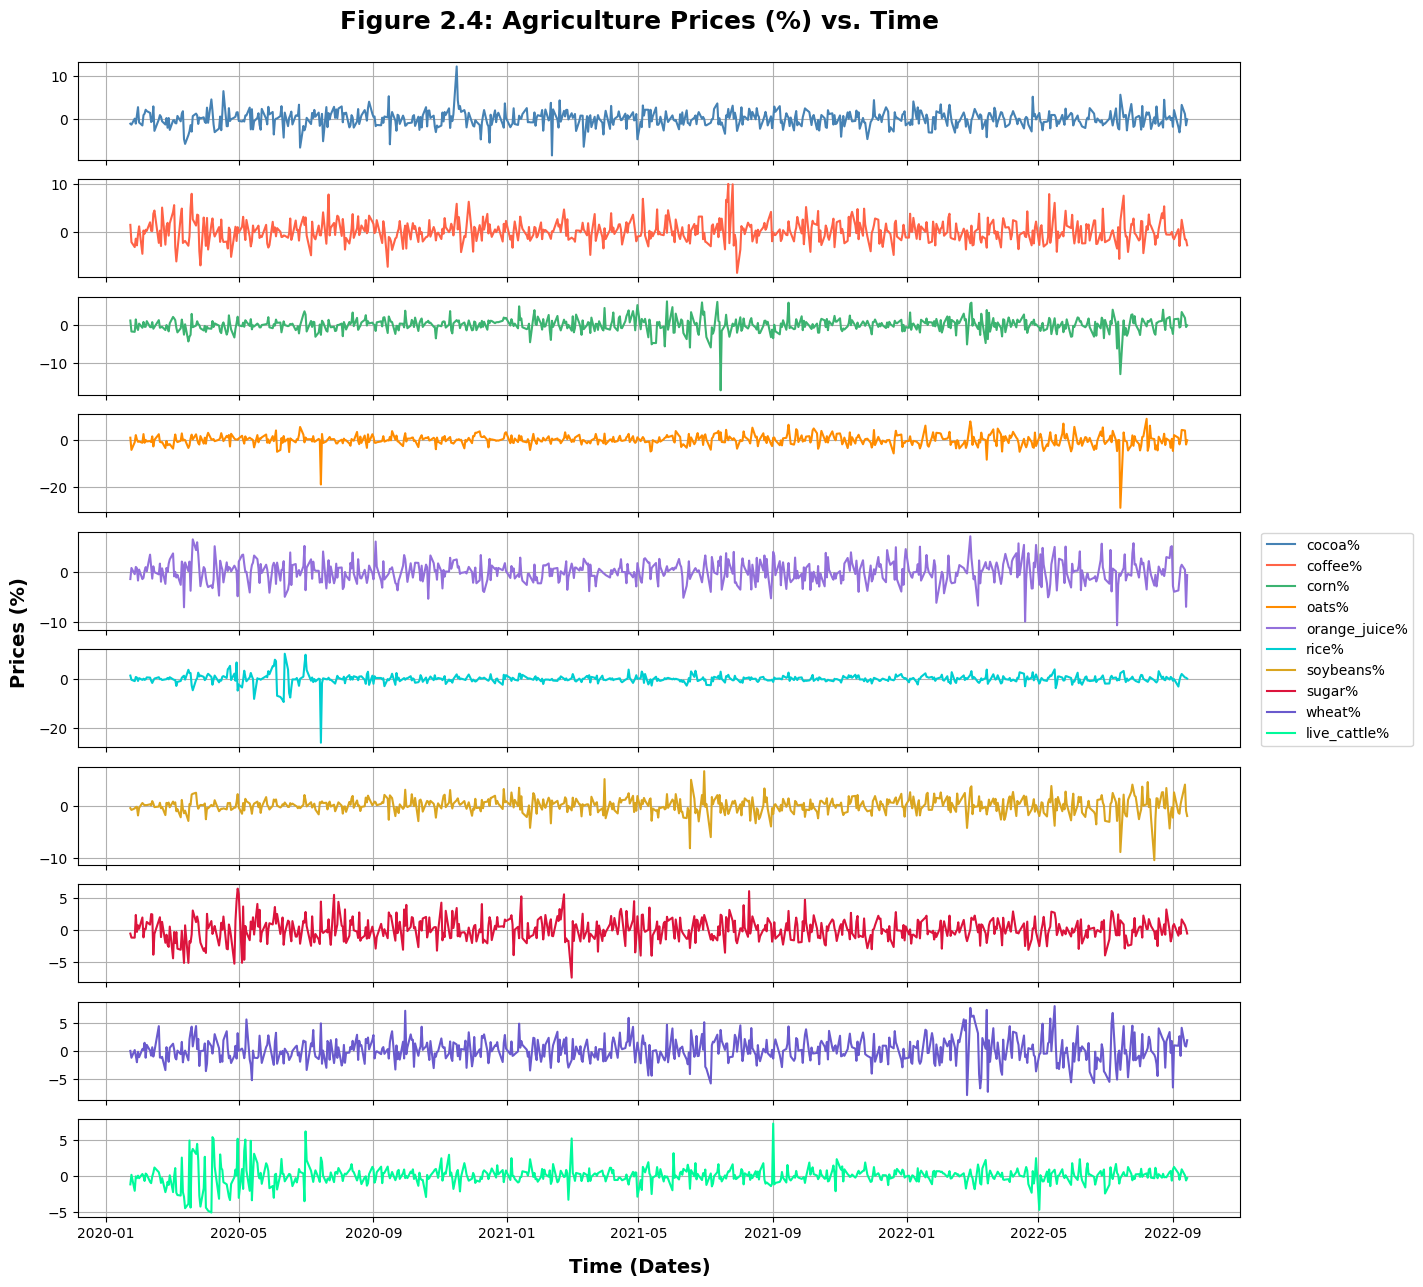

In [32]:
title = 'Figure 2.4: Agriculture Prices (%) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.155, 5.9)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (%)')

matplotlibx.set_line_multichart_fig_dims(15.0, 15.0)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.075)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.07)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(agr_pct_df, title)

## <br> **Section 3: Exchange Rates (USD)**

### **3.1: Extract Exchange Rates (USD)**

In [33]:
euro_pcs_series = assetx.rtn_cmdt_prices('currencies', 'eur')

logx.log_write_obj(euro_pcs_series)

In [34]:
aud_pcs_series  = assetx.rtn_cmdt_prices('currencies', 'aud')

logx.log_write_obj(aud_pcs_series)

In [35]:
cad_pcs_series  = assetx.rtn_cmdt_prices('currencies', 'cad')

logx.log_write_obj(cad_pcs_series)

In [36]:
sgd_pcs_series  = assetx.rtn_cmdt_prices('currencies', 'sgd')

logx.log_write_obj(sgd_pcs_series)

In [37]:
btc_pcs_series  = assetx.rtn_cmdt_prices('currencies', 'bitcoin')

logx.log_write_obj(btc_pcs_series)

### **3.2: Transform Exchange Rates (USD)**

In [38]:
ttl_dict \
    = {'eur':     euro_pcs_series,
       'aud':     aud_pcs_series,
       'cad':     cad_pcs_series,
       'sgd':     sgd_pcs_series,
       'bitcoin': btc_pcs_series}

exchg_rts_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(exchg_rts_df)

In [39]:
title = 'Table 3.2: Exchange Rates (USD)'

fmt_dict \
    = {'eur':     pandasx.fmt_dict['curr_flt'],
       'aud':     pandasx.fmt_dict['curr_flt'],
       'cad':     pandasx.fmt_dict['curr_flt'],
       'sgd':     pandasx.fmt_dict['curr_flt'],
       'bitcoin': pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(exchg_rts_df, title, hide_idx_bool = False).format(fmt_dict)

,eur,aud,cad,sgd,bitcoin
2020-01-22,$1.11,$0.68,$0.76,$0.74,"$8,680.88"
2020-01-23,$1.11,$0.68,$0.76,$0.74,"$8,406.52"
2020-01-24,$1.11,$0.68,$0.76,$0.74,"$8,445.43"
2020-01-27,$1.10,$0.68,$0.76,$0.74,"$8,909.82"
2020-01-28,$1.10,$0.68,$0.76,$0.74,"$9,358.59"
2020-01-29,$1.10,$0.68,$0.76,$0.74,"$9,316.63"
2020-01-30,$1.10,$0.68,$0.76,$0.74,"$9,508.99"
2020-01-31,$1.10,$0.67,$0.76,$0.73,"$9,350.53"
2020-02-03,$1.11,$0.67,$0.76,$0.73,"$9,293.52"
2020-02-04,$1.11,$0.67,$0.75,$0.73,"$9,180.96"


### **3.3: Correlation (Spearman): Exchange Rates (USD)**

In [40]:
title = 'Table 3.3: Correlation (Spearman): Exchange Rates (USD)'

pandasx.rtn_fmt_tbl(exchg_rts_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,eur,aud,cad,sgd,bitcoin
eur,1.00,0.79,0.43,0.81,0.33
aud,0.79,1.00,0.79,0.89,0.70
cad,0.43,0.79,1.00,0.72,0.85
sgd,0.81,0.89,0.72,1.00,0.63
bitcoin,0.33,0.70,0.85,0.63,1.00


### **3.4: Display Exchange Rates (USD)**

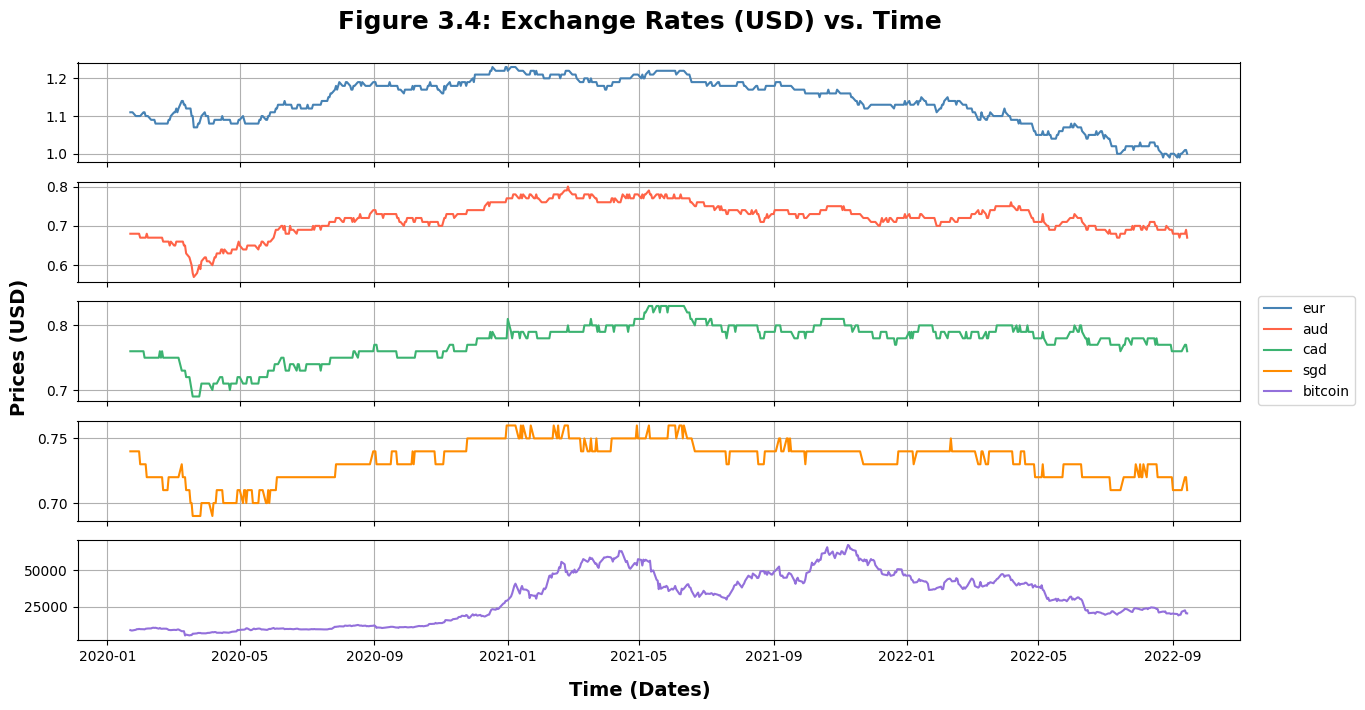

In [41]:
title = 'Figure 3.4: Exchange Rates (USD) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.105, 2.908)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (USD)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(exchg_rts_df, title)

### **3.5: Load Exchange Rates (USD)**

In [42]:
exchg_rts_df.to_json(assetx.config_dict['file']['exchg_rts'], mode = 'w')

## <br> **Section 4: Exchange Rates (%)**

### **4.1: Calculate Exchange Rates (%)**

In [43]:
euro_pcs_pct_series = dtypesx.cnv_to_pct_chg(euro_pcs_series)

logx.log_write_obj(euro_pcs_pct_series)

In [44]:
aud_pcs_pct_series  = dtypesx.cnv_to_pct_chg(aud_pcs_series)

logx.log_write_obj(aud_pcs_pct_series)

In [45]:
cad_pcs_pct_series  = dtypesx.cnv_to_pct_chg(cad_pcs_series)

logx.log_write_obj(cad_pcs_pct_series)

In [46]:
sgd_pcs_pct_series  = dtypesx.cnv_to_pct_chg(sgd_pcs_series)

logx.log_write_obj(sgd_pcs_pct_series)

In [47]:
btc_pcs_pct_series  = dtypesx.cnv_to_pct_chg(btc_pcs_series)

logx.log_write_obj(btc_pcs_pct_series)

### **4.2: Transform Exchange Rates (%)**

In [48]:
ttl_dict \
    = {'eur%':     euro_pcs_pct_series,
       'aud%':     aud_pcs_pct_series,
       'cad%':     cad_pcs_pct_series,
       'sgd%':     sgd_pcs_pct_series,
       'bitcoin%': btc_pcs_pct_series}

exchg_rts_pct_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(exchg_rts_pct_df)

In [49]:
title = 'Table 4.2: Exchange Rates (%)'

fmt_dict \
    = {'eur%':     pandasx.fmt_dict['pct_flt'],
       'aud%':     pandasx.fmt_dict['pct_flt'],
       'cad%':     pandasx.fmt_dict['pct_flt'],
       'sgd%':     pandasx.fmt_dict['pct_flt'],
       'bitcoin%': pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(exchg_rts_pct_df, title, hide_idx_bool = False).format(fmt_dict)

,eur%,aud%,cad%,sgd%,bitcoin%
2020-01-23,0.00%,0.00%,0.00%,0.00%,-3.16%
2020-01-24,0.00%,0.00%,0.00%,0.00%,0.46%
2020-01-27,-0.90%,0.00%,0.00%,0.00%,3.64%
2020-01-28,0.00%,0.00%,0.00%,0.00%,5.04%
2020-01-29,0.00%,0.00%,0.00%,0.00%,-0.45%
2020-01-30,0.00%,0.00%,0.00%,0.00%,2.06%
2020-01-31,0.00%,-1.47%,0.00%,-1.35%,-1.67%
2020-02-03,0.91%,0.00%,0.00%,0.00%,-0.54%
2020-02-04,0.00%,0.00%,-1.32%,0.00%,-1.21%
2020-02-05,-0.90%,0.00%,0.00%,0.00%,4.71%


### **4.3: Correlation (Spearman): Exchange Rates (%)**

In [50]:
title = 'Table 4.3: Correlation (Spearman): Exchange Rates (%)'

pandasx.rtn_fmt_tbl(exchg_rts_pct_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,eur%,aud%,cad%,sgd%,bitcoin%
eur%,1.00,0.34,0.22,0.26,-0.03
aud%,0.34,1.00,0.39,0.33,-0.13
cad%,0.22,0.39,1.00,0.29,-0.05
sgd%,0.26,0.33,0.29,1.00,-0.07
bitcoin%,-0.03,-0.13,-0.05,-0.07,1.00


### **4.4: Display Exchange Rates (%)**

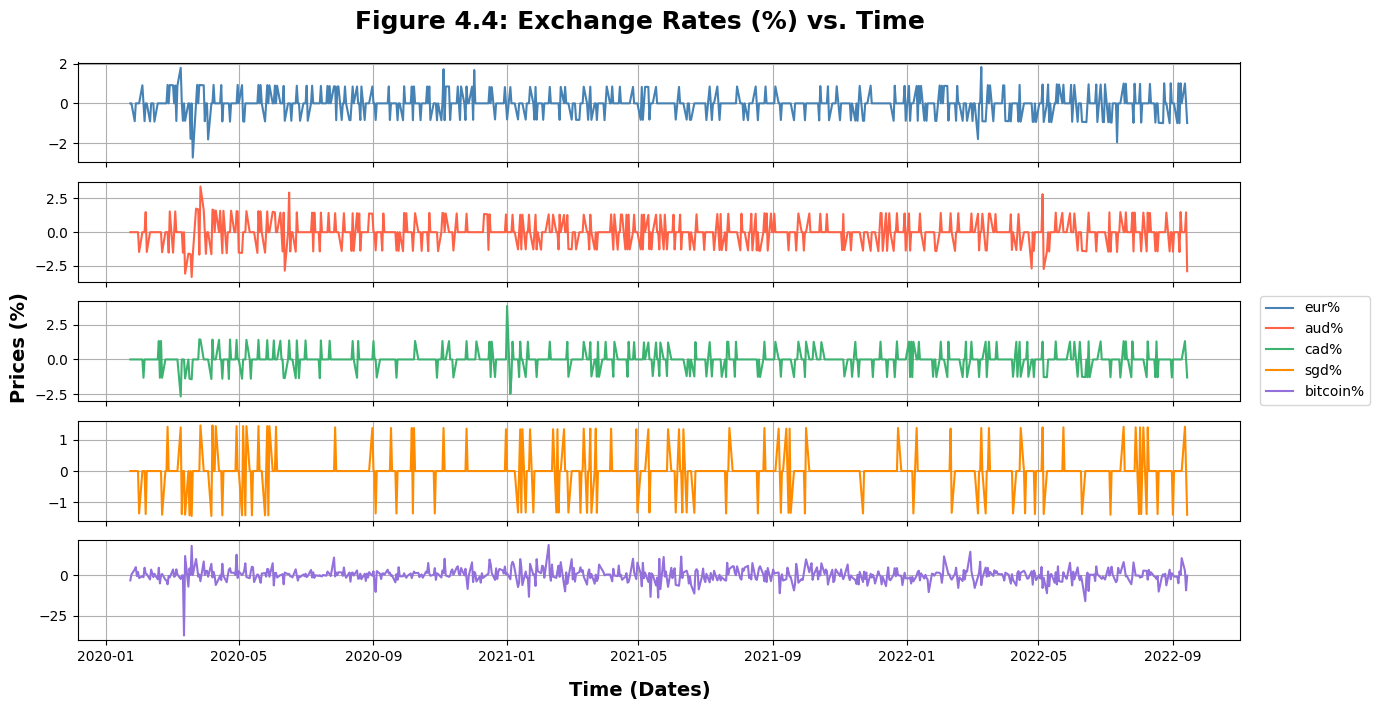

In [51]:
title = 'Figure 4.4: Exchange Rates (%) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.118, 2.91)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (%)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(exchg_rts_pct_df, title)

## <br> **Section 5: Interest Rates**

### **5.1: Extract Interest Rates**

In [52]:
treas_bond_series    = assetx.rtn_cmdt_prices('yields', 'treas_bond')

logx.log_write_obj(treas_bond_series)

In [53]:
treas_5_year_series  = assetx.rtn_cmdt_prices('yields', 'treas_5_year')

logx.log_write_obj(treas_5_year_series)

In [54]:
treas_10_year_series = assetx.rtn_cmdt_prices('yields', 'treas_10_year')

logx.log_write_obj(treas_10_year_series)

In [55]:
treas_30_year_series = assetx.rtn_cmdt_prices('yields', 'treas_30_year')

logx.log_write_obj(treas_30_year_series)

In [56]:
cboe_10_year_series  = assetx.rtn_cmdt_prices('yields', 'cboe')

logx.log_write_obj(cboe_10_year_series)

### **5.2: Transform Interest Rates**

In [57]:
ttl_dict \
    = {'treas_bond':    treas_bond_series,
       'treas_5_year':  treas_5_year_series,
       'treas_10_year': treas_10_year_series,
       'treas_30_year': treas_30_year_series,
       'cboe_10_year':  cboe_10_year_series}

intrt_rts_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(intrt_rts_df)

In [58]:
title = 'Table 5.2: Interest Rates'

fmt_dict \
    = {'treas_bond':    pandasx.fmt_dict['flt'],
       'treas_5_year':  pandasx.fmt_dict['flt'],
       'treas_10_year': pandasx.fmt_dict['flt'],
       'treas_30_year': pandasx.fmt_dict['flt'],
       'cboe_10_year':  pandasx.fmt_dict['flt']}

pandasx.rtn_fmt_tbl(intrt_rts_df, title, hide_idx_bool = False).format(fmt_dict)

,treas_bond,treas_5_year,treas_10_year,treas_30_year,cboe_10_year
2020-01-22,158.81,1.57,129.55,2.22,1.77
2020-01-23,159.56,1.55,129.78,2.18,1.74
2020-01-24,160.62,1.50,130.28,2.13,1.68
2020-01-27,162.03,1.43,130.89,2.06,1.61
2020-01-28,161.31,1.47,130.61,2.10,1.64
2020-01-29,162.25,1.42,131.02,2.05,1.59
2020-01-30,162.91,1.38,131.31,2.03,1.56
2020-01-31,163.53,1.33,131.66,2.02,1.52
2020-02-03,163.78,1.34,131.58,2.00,1.52
2020-02-04,162.09,1.42,130.89,2.08,1.60


### **5.3: Correlation (Spearman): Interest Rates**

In [59]:
title = 'Table 5.3: Correlation (Spearman): Interest-Bearing Asset Prices'

pandasx.rtn_fmt_tbl(intrt_rts_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,treas_bond,treas_5_year,treas_10_year,treas_30_year,cboe_10_year
treas_bond,1.00,-0.93,0.95,-0.98,-0.99
treas_5_year,-0.93,1.00,-0.99,0.88,0.96
treas_10_year,0.95,-0.99,1.00,-0.91,-0.98
treas_30_year,-0.98,0.88,-0.91,1.00,0.97
cboe_10_year,-0.99,0.96,-0.98,0.97,1.00


### **5.4: Display Interest Rates**

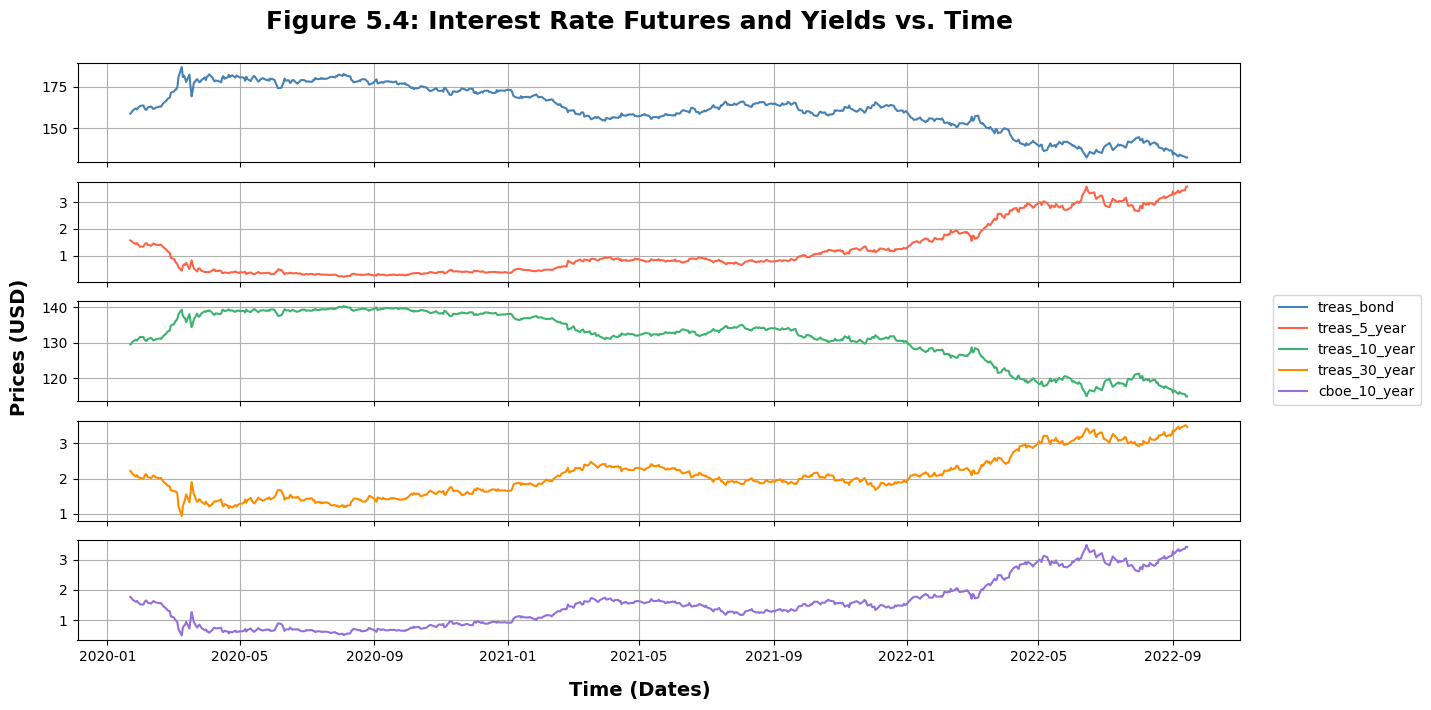

In [60]:
title = 'Figure 5.4: Interest Rate Futures and Yields vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.162, 2.91)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (USD)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(intrt_rts_df, title)

### **5.5: Load Interest Rates**

In [61]:
intrt_rts_df.to_json(assetx.config_dict['file']['intrt_rts'], mode = 'w')

## <br> **Section 6: Interest Rates (%)**

### **6.1: Calculate Interest Rates (%)**

In [62]:
treas_bond_pct_series    = dtypesx.cnv_to_pct_chg(treas_bond_series)

logx.log_write_obj(treas_bond_pct_series)

In [63]:
treas_5_year_pct_series  = dtypesx.cnv_to_pct_chg(treas_5_year_series)

logx.log_write_obj(treas_5_year_pct_series)

In [64]:
treas_10_year_pct_series = dtypesx.cnv_to_pct_chg(treas_10_year_series)

logx.log_write_obj(treas_10_year_pct_series)

In [65]:
treas_30_year_pct_series = dtypesx.cnv_to_pct_chg(treas_30_year_series)

logx.log_write_obj(treas_30_year_pct_series)

In [66]:
cboe_10_year_pct_series  = dtypesx.cnv_to_pct_chg(cboe_10_year_series)

logx.log_write_obj(cboe_10_year_series)

### **6.2: Transform Interest Rates (%)**

In [67]:
ttl_dict \
    = {'treas_bond%':    treas_bond_pct_series,
       'treas_5_year%':  treas_5_year_pct_series,
       'treas_10_year%': treas_10_year_pct_series,
       'treas_30_year%': treas_30_year_pct_series,
       'cboe_10_year%':  cboe_10_year_pct_series}

intrt_rts_pct_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(intrt_rts_pct_df)

In [68]:
title = 'Table 6.2: Interest Rates (%)'

fmt_dict \
    = {'treas_bond%':    pandasx.fmt_dict['pct_flt'],
       'treas_5_year%':  pandasx.fmt_dict['pct_flt'],
       'treas_10_year%': pandasx.fmt_dict['pct_flt'],
       'treas_30_year%': pandasx.fmt_dict['pct_flt'],
       'cboe_10_year%':  pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(intrt_rts_pct_df, title, hide_idx_bool = False).format(fmt_dict)

,treas_bond%,treas_5_year%,treas_10_year%,treas_30_year%,cboe_10_year%
2020-01-23,0.47%,-1.27%,0.18%,-1.80%,-1.69%
2020-01-24,0.66%,-3.23%,0.39%,-2.29%,-3.45%
2020-01-27,0.88%,-4.67%,0.47%,-3.29%,-4.17%
2020-01-28,-0.44%,2.80%,-0.21%,1.94%,1.86%
2020-01-29,0.58%,-3.40%,0.31%,-2.38%,-3.05%
2020-01-30,0.41%,-2.82%,0.22%,-0.98%,-1.89%
2020-01-31,0.38%,-3.62%,0.27%,-0.49%,-2.56%
2020-02-03,0.15%,0.75%,-0.06%,-0.99%,0.00%
2020-02-04,-1.03%,5.97%,-0.52%,4.00%,5.26%
2020-02-05,-0.60%,2.82%,-0.26%,2.40%,3.12%


### **6.3: Correlation (Spearman): Interest-Bearing Asset Prices (%)**

In [69]:
title = 'Table 6.3: Correlation (Spearman): Interest Rates (%)'

pandasx.rtn_fmt_tbl(intrt_rts_pct_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,treas_bond%,treas_5_year%,treas_10_year%,treas_30_year%,cboe_10_year%
treas_bond%,1.00,-0.79,0.92,-0.93,-0.93
treas_5_year%,-0.79,1.00,-0.87,0.74,0.89
treas_10_year%,0.92,-0.87,1.00,-0.81,-0.90
treas_30_year%,-0.93,0.74,-0.81,1.00,0.93
cboe_10_year%,-0.93,0.89,-0.90,0.93,1.00


### **6.4: Display Interest-Bearing Asset Prices (%)**

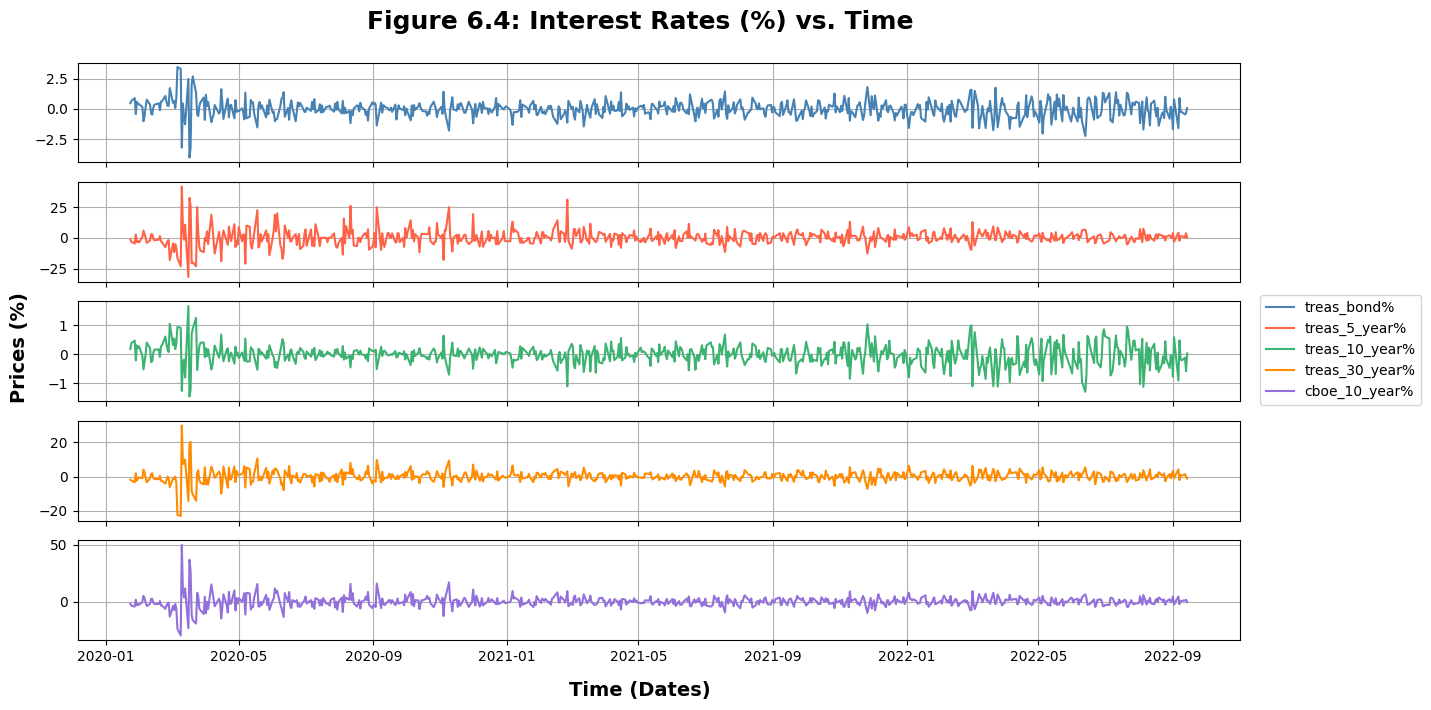

In [70]:
title = 'Figure 6.4: Interest Rates (%) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.162, 2.91)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (%)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(intrt_rts_pct_df, title)

## <br> **Section 7: Metals Prices**

### **7.1: Extract Metals Prices**

In [71]:
au_pcs_series = assetx.rtn_cmdt_prices('metals', 'gold')

logx.log_write_obj(au_pcs_series)

In [72]:
ag_pcs_series = assetx.rtn_cmdt_prices('metals', 'silver')

logx.log_write_obj(ag_pcs_series)

In [73]:
pt_pcs_series = assetx.rtn_cmdt_prices('metals', 'platinum')

logx.log_write_obj(pt_pcs_series)

In [74]:
pd_pcs_series = assetx.rtn_cmdt_prices('metals', 'palladium')

logx.log_write_obj(pd_pcs_series)

In [75]:
cu_pcs_series = assetx.rtn_cmdt_prices('metals', 'copper')

logx.log_write_obj(cu_pcs_series)

### **7.2: Transform Metals Prices**

In [76]:
ttl_dict \
    = {'gold':      au_pcs_series,
       'silver':    ag_pcs_series,
       'platinum':  pt_pcs_series,
       'palladium': pd_pcs_series,
       'copper':    cu_pcs_series}

metals_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(metals_df)

In [77]:
title = 'Table 7.2: Metals Prices'

fmt_dict \
    = {'gold':      pandasx.fmt_dict['curr_flt'],
       'silver':    pandasx.fmt_dict['curr_flt'],
       'platinum':  pandasx.fmt_dict['curr_flt'],
       'palladium': pandasx.fmt_dict['curr_flt'],
       'copper':    pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(metals_df, title, hide_idx_bool = False).format(fmt_dict)

,gold,silver,platinum,palladium,copper
2020-01-22,"$1,555.30",$17.77,"$1,015.80","$2,348.60",$17.77
2020-01-23,"$1,564.60",$17.77,"$1,001.70","$2,342.00",$17.77
2020-01-24,"$1,571.10",$18.06,"$1,005.20","$2,329.30",$18.06
2020-01-27,"$1,576.80",$18.00,$985.90,"$2,208.60",$18.00
2020-01-28,"$1,569.20",$17.40,$990.10,"$2,230.10",$17.40
2020-01-29,"$1,569.80",$17.43,$968.60,"$2,247.20",$17.43
2020-01-30,"$1,583.50",$17.95,$977.10,"$2,237.60",$17.95
2020-01-31,"$1,582.90",$17.97,$959.20,"$2,246.60",$17.97
2020-02-03,"$1,577.20",$17.64,$968.00,"$2,255.40",$17.64
2020-02-04,"$1,550.40",$17.53,$963.40,"$2,357.50",$17.53


### **7.3: Correlation (Spearman): Metals Prices**

In [78]:
title = 'Table 7.3: Correlation (Spearman): Metals Prices'

pandasx.rtn_fmt_tbl(metals_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,gold,silver,platinum,palladium,copper
gold,1.00,0.64,0.26,0.27,0.64
silver,0.64,1.00,0.76,0.65,1.00
platinum,0.26,0.76,1.00,0.65,0.76
palladium,0.27,0.65,0.65,1.00,0.65
copper,0.64,1.00,0.76,0.65,1.00


### **7.4: Display Metals Prices**

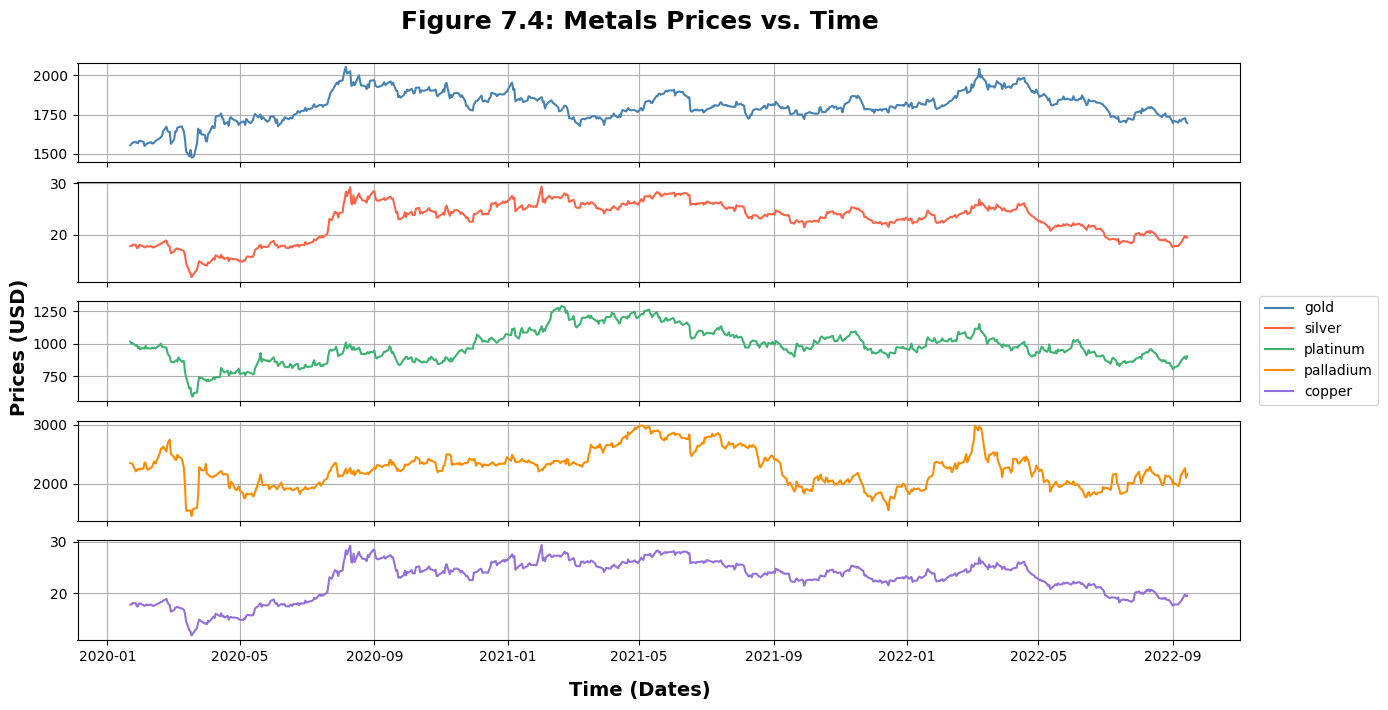

In [79]:
title = 'Figure 7.4: Metals Prices vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.125, 2.91)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (USD)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(metals_df, title)

### **7.5: Load Metals Prices**

In [80]:
metals_df.to_json(assetx.config_dict['file']['metals'], mode = 'w')

## <br> **Section 8: Metals Prices (%)**

### **8.1: Calculate Metals Prices (%)**

In [81]:
au_pcs_pct_series = dtypesx.cnv_to_pct_chg(au_pcs_series)

logx.log_write_obj(au_pcs_pct_series)

In [82]:
ag_pcs_pct_series = dtypesx.cnv_to_pct_chg(ag_pcs_series)

logx.log_write_obj(ag_pcs_pct_series)

In [83]:
pt_pcs_pct_series = dtypesx.cnv_to_pct_chg(pt_pcs_series)

logx.log_write_obj(pt_pcs_pct_series)

In [84]:
pd_pcs_pct_series = dtypesx.cnv_to_pct_chg(pd_pcs_series)

logx.log_write_obj(pd_pcs_pct_series)

In [85]:
cu_pcs_pct_series = dtypesx.cnv_to_pct_chg(cu_pcs_series)

logx.log_write_obj(cu_pcs_pct_series)

### **8.2: Transform Metals Prices (%)**

In [86]:
ttl_dict \
    = {'gold%':      au_pcs_pct_series,
       'silver%':    ag_pcs_pct_series,
       'platinum%':  pt_pcs_pct_series,
       'palladium%': pd_pcs_pct_series,
       'copper%':    cu_pcs_pct_series}

metals_pct_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(metals_pct_df)

In [87]:
title = 'Table 8.2: Metals Prices (%)'

fmt_dict \
    = {'gold%':      pandasx.fmt_dict['pct_flt'],
       'silver%':    pandasx.fmt_dict['pct_flt'],
       'platinum%':  pandasx.fmt_dict['pct_flt'],
       'palladium%': pandasx.fmt_dict['pct_flt'],
       'copper%':    pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(metals_pct_df, title, hide_idx_bool = False).format(fmt_dict)

,gold%,silver%,platinum%,palladium%,copper%
2020-01-23,0.60%,0.00%,-1.39%,-0.28%,0.00%
2020-01-24,0.42%,1.63%,0.35%,-0.54%,1.63%
2020-01-27,0.36%,-0.33%,-1.92%,-5.18%,-0.33%
2020-01-28,-0.48%,-3.33%,0.43%,0.97%,-3.33%
2020-01-29,0.04%,0.17%,-2.17%,0.77%,0.17%
2020-01-30,0.87%,2.98%,0.88%,-0.43%,2.98%
2020-01-31,-0.04%,0.11%,-1.83%,0.40%,0.11%
2020-02-03,-0.36%,-1.84%,0.92%,0.39%,-1.84%
2020-02-04,-1.70%,-0.62%,-0.48%,4.53%,-0.62%
2020-02-05,0.48%,0.23%,2.18%,-0.38%,0.23%


### **8.3: Correlation (Spearman): Metals Prices (%)**

In [88]:
title = 'Table 8.3: Correlation (Spearman): Metals Prices (%)'

pandasx.rtn_fmt_tbl(metals_pct_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,gold%,silver%,platinum%,palladium%,copper%
gold%,1.00,0.76,0.55,0.37,0.76
silver%,0.76,1.00,0.64,0.45,1.00
platinum%,0.55,0.64,1.00,0.53,0.64
palladium%,0.37,0.45,0.53,1.00,0.45
copper%,0.76,1.00,0.64,0.45,1.00


### **8.4: Display Metals Prices (%)**

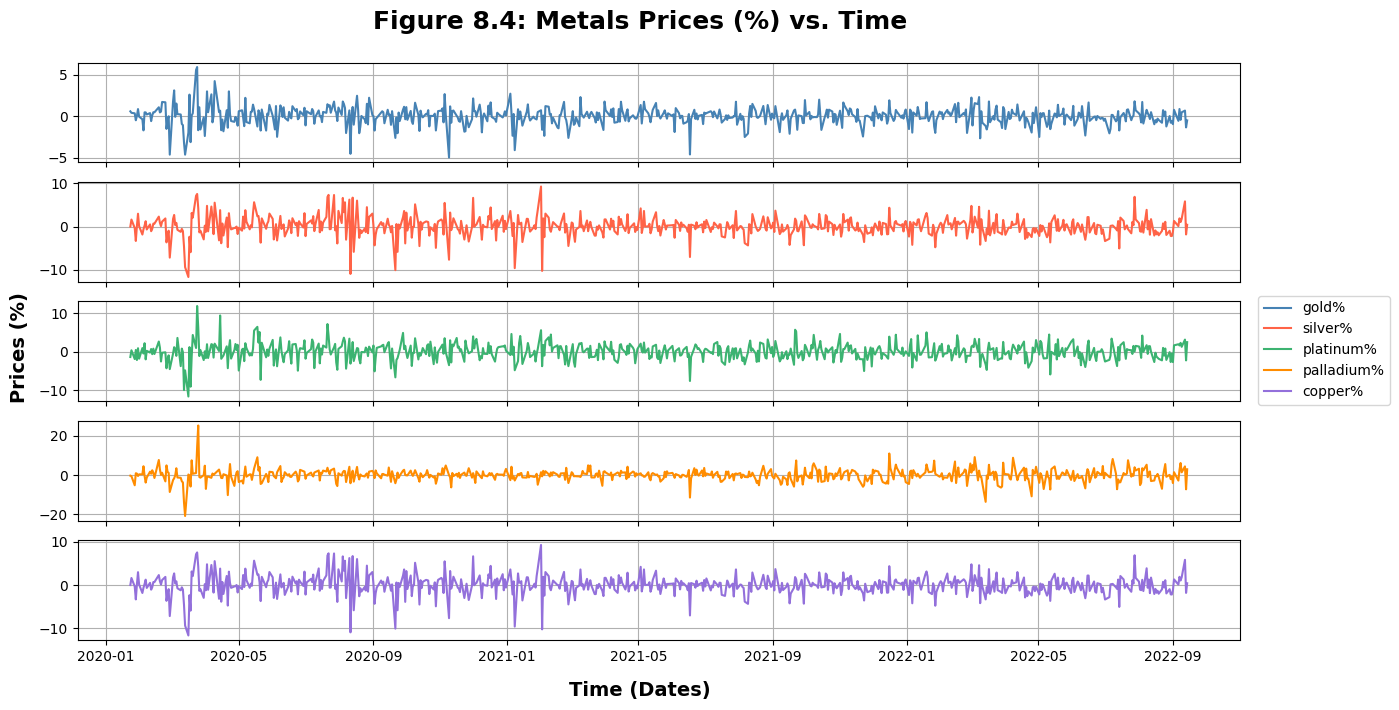

In [89]:
title = 'Figure 8.4: Metals Prices (%) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.135, 2.91)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (%)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(metals_pct_df, title)

## <br> **Section 9: Petroleum Prices**

### **9.1: Extract Petroleum Prices**

In [90]:
brnt_crd_oil_pcs_series = assetx.rtn_cmdt_prices('petroleum', 'brent_crude_oil')

logx.log_write_obj(brnt_crd_oil_pcs_series)

In [91]:
crd_oil_wti_pcs_series  = assetx.rtn_cmdt_prices('petroleum', 'crude_oil_wti')

logx.log_write_obj(crd_oil_wti_pcs_series)

In [92]:
rbob_gas_pcs_series     = assetx.rtn_cmdt_prices('petroleum', 'rbob_gasoline')

logx.log_write_obj(rbob_gas_pcs_series)

In [93]:
htg_oil_pcs_series      = assetx.rtn_cmdt_prices('petroleum', 'heating_oil')

logx.log_write_obj(htg_oil_pcs_series)

In [94]:
ntrl_gas_pcs_series     = assetx.rtn_cmdt_prices('petroleum', 'natural_gas')

logx.log_write_obj(ntrl_gas_pcs_series)

### **9.2: Transform Petroleum Prices**

In [95]:
ttl_dict \
    = {'brent_crude_oil': brnt_crd_oil_pcs_series,
       'crude_oil_wti':   crd_oil_wti_pcs_series,
       'rbob_gasoline':   rbob_gas_pcs_series,
       'heating_oil':     htg_oil_pcs_series,
       'natural_gas':     ntrl_gas_pcs_series}

petrol_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(petrol_df)

In [96]:
title = 'Table 9.2: Petroleum Prices'

fmt_dict \
    = {'brent_crude_oil': pandasx.fmt_dict['curr_flt'],
       'crude_oil_wti':   pandasx.fmt_dict['curr_flt'],
       'rbob_gasoline':   pandasx.fmt_dict['curr_flt'],
       'heating_oil':     pandasx.fmt_dict['curr_flt'],
       'natural_gas':     pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(petrol_df, title, hide_idx_bool = False).format(fmt_dict)

,brent_crude_oil,crude_oil_wti,rbob_gasoline,heating_oil,natural_gas
2020-01-22,$63.21,$56.74,$1.58,$1.80,$1.90
2020-01-23,$62.04,$55.59,$1.56,$1.79,$1.93
2020-01-24,$60.69,$54.19,$1.52,$1.73,$1.89
2020-01-27,$59.32,$53.14,$1.48,$1.68,$1.90
2020-01-28,$59.51,$53.48,$1.50,$1.72,$1.93
2020-01-29,$59.81,$53.33,$1.53,$1.70,$1.88
2020-01-30,$58.29,$52.14,$1.49,$1.64,$1.83
2020-01-31,$58.16,$51.56,$1.49,$1.62,$1.84
2020-02-03,$54.45,$50.11,$1.47,$1.58,$1.82
2020-02-04,$53.96,$49.61,$1.44,$1.58,$1.87


### **9.3: Correlation (Spearman): Petroleum Prices**

In [97]:
title = 'Table 9.3: Correlation (Spearman): Petroleum Prices'

pandasx.rtn_fmt_tbl(petrol_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,brent_crude_oil,crude_oil_wti,rbob_gasoline,heating_oil,natural_gas
brent_crude_oil,1.00,1.00,0.99,0.99,0.91
crude_oil_wti,1.00,1.00,0.99,0.99,0.91
rbob_gasoline,0.99,0.99,1.00,0.99,0.90
heating_oil,0.99,0.99,0.99,1.00,0.92
natural_gas,0.91,0.91,0.90,0.92,1.00


### **9.4: Display Petroleum Prices**

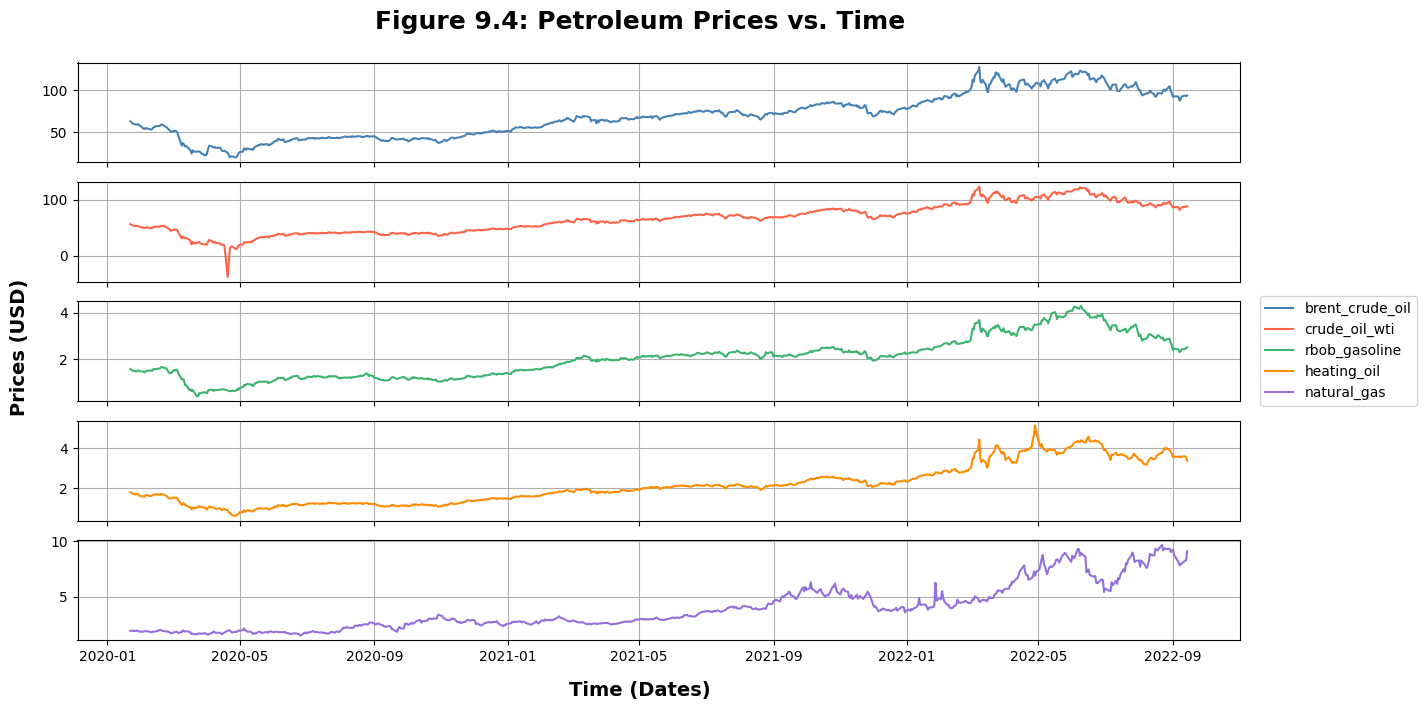

In [98]:
title = 'Figure 9.4: Petroleum Prices vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.158, 2.9)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (USD)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(petrol_df, title)

### **9.5: Load Petroleum Prices**

In [99]:
petrol_df.to_json(assetx.config_dict['file']['petrol'], mode = 'w')

## <br> **Section 10: Petroleum Prices (%)**

### **10.1: Calculate Petroleum Prices (%)**

In [100]:
brnt_crd_oil_pcs_pct_series  = dtypesx.cnv_to_pct_chg(brnt_crd_oil_pcs_series)

logx.log_write_obj(brnt_crd_oil_pcs_pct_series)

In [101]:
crd_oil_wti_pcs_pct_series   = dtypesx.cnv_to_pct_chg(crd_oil_wti_pcs_series)

logx.log_write_obj(crd_oil_wti_pcs_pct_series)

In [102]:
rbob_gasoline_pcs_pct_series = dtypesx.cnv_to_pct_chg(rbob_gas_pcs_series)

logx.log_write_obj(rbob_gasoline_pcs_pct_series)

In [103]:
htg_oil_pcs_pct_series       = dtypesx.cnv_to_pct_chg(htg_oil_pcs_series)

logx.log_write_obj(htg_oil_pcs_pct_series)

In [104]:
ntrl_gas_pcs_pct_series      = dtypesx.cnv_to_pct_chg(ntrl_gas_pcs_series)

logx.log_write_obj(ntrl_gas_pcs_pct_series)

### **10.2: Transform Petroleum Prices (%)**

In [105]:
ttl_dict \
    = {'brent_crude_oil%': brnt_crd_oil_pcs_pct_series,
       'crude_oil_wti%':   crd_oil_wti_pcs_pct_series,
       'rbob_gasoline%':   rbob_gasoline_pcs_pct_series,
       'heating_oil%':     htg_oil_pcs_pct_series,
       'natural_gas%':     ntrl_gas_pcs_pct_series}

petrol_pct_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(petrol_pct_df)

In [106]:
title = 'Table 10.2: Petroleum Prices (%)'

fmt_dict \
    = {'brent_crude_oil%': pandasx.fmt_dict['pct_flt'],
       'crude_oil_wti%':   pandasx.fmt_dict['pct_flt'],
       'rbob_gasoline%':   pandasx.fmt_dict['pct_flt'],
       'heating_oil%':     pandasx.fmt_dict['pct_flt'],
       'natural_gas%':     pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(petrol_pct_df, title, hide_idx_bool = False).format(fmt_dict)

,brent_crude_oil%,crude_oil_wti%,rbob_gasoline%,heating_oil%,natural_gas%
2020-01-23,-1.85%,-2.03%,-1.27%,-0.56%,1.58%
2020-01-24,-2.18%,-2.52%,-2.56%,-3.35%,-2.07%
2020-01-27,-2.26%,-1.94%,-2.63%,-2.89%,0.53%
2020-01-28,0.32%,0.64%,1.35%,2.38%,1.58%
2020-01-29,0.50%,-0.28%,2.00%,-1.16%,-2.59%
2020-01-30,-2.54%,-2.23%,-2.61%,-3.53%,-2.66%
2020-01-31,-0.22%,-1.11%,0.00%,-1.22%,0.55%
2020-02-03,-6.38%,-2.81%,-1.34%,-2.47%,-1.09%
2020-02-04,-0.90%,-1.00%,-2.04%,0.00%,2.75%
2020-02-05,2.45%,2.30%,3.47%,4.43%,-0.53%


### **Correlation (Spearman): Petroleum Prices (%)**

In [107]:
title = 'Table 10.3: Correlation (Spearman): Petroleum Prices (%)'

pandasx.rtn_fmt_tbl(petrol_pct_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,brent_crude_oil%,crude_oil_wti%,rbob_gasoline%,heating_oil%,natural_gas%
brent_crude_oil%,1.00,0.92,0.77,0.75,0.08
crude_oil_wti%,0.92,1.00,0.75,0.73,0.09
rbob_gasoline%,0.77,0.75,1.00,0.69,0.10
heating_oil%,0.75,0.73,0.69,1.00,0.12
natural_gas%,0.08,0.09,0.10,0.12,1.00


### **Display Petroleum Prices (%)**

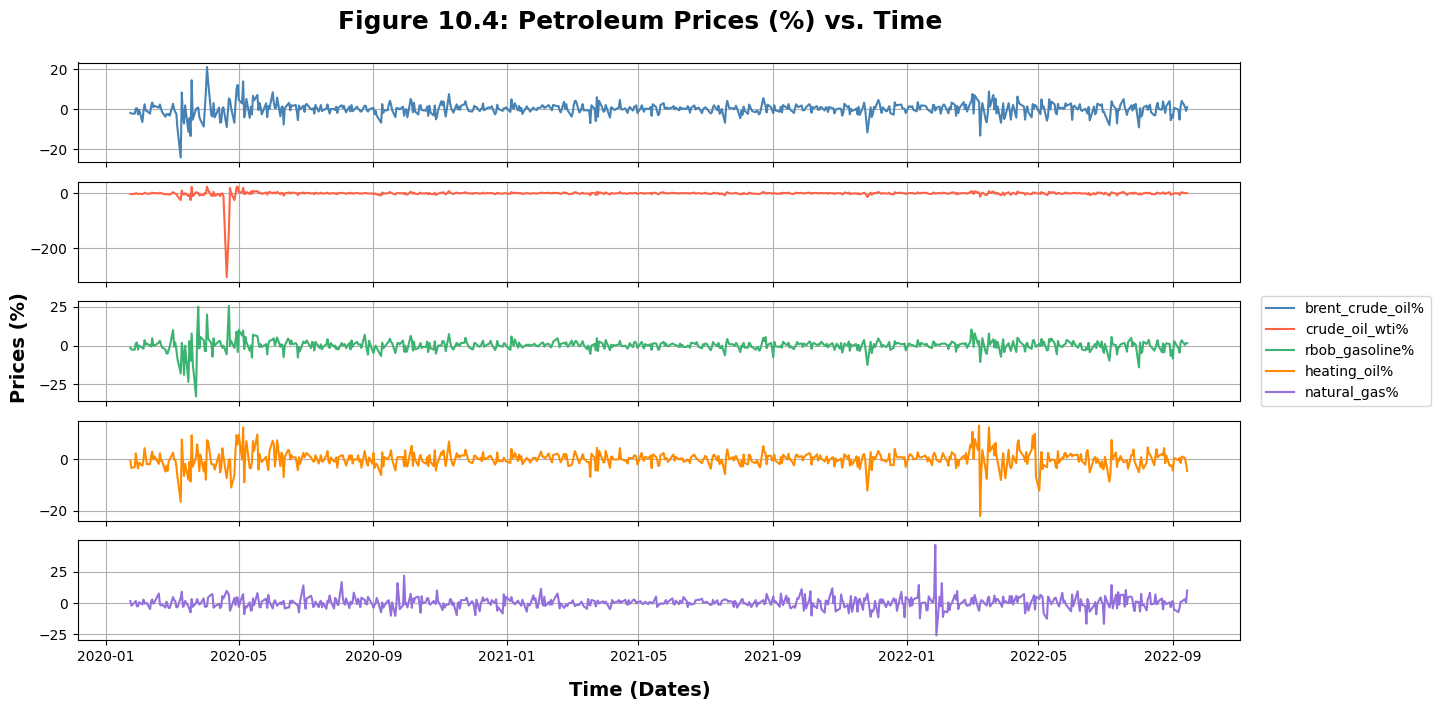

In [108]:
title = 'Figure 10.4: Petroleum Prices (%) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.17, 2.9)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (%)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(petrol_pct_df, title)

## <br> **Section 11: Stock Market Indices**

### **11.1: Extract Stock Market Indices**

In [109]:
sp500_pcs_series   = assetx.rtn_cmdt_prices('indices', 'sp500')

logx.log_write_obj(sp500_pcs_series)

In [110]:
djia_pcs_series    = assetx.rtn_cmdt_prices('indices', 'djia')

logx.log_write_obj(djia_pcs_series)

In [111]:
nasdaq_pcs_series  = assetx.rtn_cmdt_prices('indices', 'nasdaq')

logx.log_write_obj(nasdaq_pcs_series)

In [112]:
nyse_pcs_series    = assetx.rtn_cmdt_prices('indices', 'nyse')

logx.log_write_obj(nyse_pcs_series)

In [113]:
russell_pcs_series = assetx.rtn_cmdt_prices('indices', 'russell')

logx.log_write_obj(russell_pcs_series)

### **11.2: Transform Stock Market Indices**

In [114]:
ttl_dict \
    = {'sp500':   sp500_pcs_series,
       'djia':    djia_pcs_series,
       'nasdaq':  nasdaq_pcs_series,
       'nyse':    nyse_pcs_series,
       'russell': russell_pcs_series}

stk_mkt_idxs_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(stk_mkt_idxs_df)

In [115]:
title = 'Table 11.2: Stock Market Indices'

fmt_dict \
    = {'sp500':   pandasx.fmt_dict['curr_flt'],
       'djia':    pandasx.fmt_dict['curr_flt'],
       'nasdaq':  pandasx.fmt_dict['curr_flt'],
       'nyse':    pandasx.fmt_dict['curr_flt'],
       'russell': pandasx.fmt_dict['curr_flt']}

pandasx.rtn_fmt_tbl(stk_mkt_idxs_df, title, hide_idx_bool = False).format(fmt_dict)

,sp500,djia,nasdaq,nyse,russell
2020-01-22,"$3,321.75","$29,186.27","$9,383.77","$14,110.24","$1,684.46"
2020-01-23,"$3,325.54","$29,160.09","$9,402.48","$14,102.04","$1,685.01"
2020-01-24,"$3,295.47","$28,989.73","$9,314.91","$13,978.47","$1,662.23"
2020-01-27,"$3,243.63","$28,535.80","$9,139.31","$13,769.60","$1,644.14"
2020-01-28,"$3,276.24","$28,722.85","$9,269.68","$13,877.61","$1,658.31"
2020-01-29,"$3,273.40","$28,734.45","$9,275.16","$13,843.81","$1,649.22"
2020-01-30,"$3,283.66","$28,859.44","$9,298.93","$13,861.92","$1,648.22"
2020-01-31,"$3,225.52","$28,256.03","$9,150.94","$13,614.10","$1,614.06"
2020-02-03,"$3,248.92","$28,399.81","$9,273.40","$13,677.92","$1,632.21"
2020-02-04,"$3,297.59","$28,807.63","$9,467.97","$13,862.84","$1,656.77"


### **11.3: Correlation (Spearman): Stock Market Indices**

In [116]:
title = 'Table 11.3: Correlation (Spearman): Stock Market Indices'

pandasx.rtn_fmt_tbl(stk_mkt_idxs_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,sp500,djia,nasdaq,nyse,russell
sp500,1.00,0.99,0.94,0.98,0.83
djia,0.99,1.00,0.94,0.99,0.87
nasdaq,0.94,0.94,1.00,0.94,0.92
nyse,0.98,0.99,0.94,1.00,0.89
russell,0.83,0.87,0.92,0.89,1.00


### **11.4: Display Stock Market Indices**

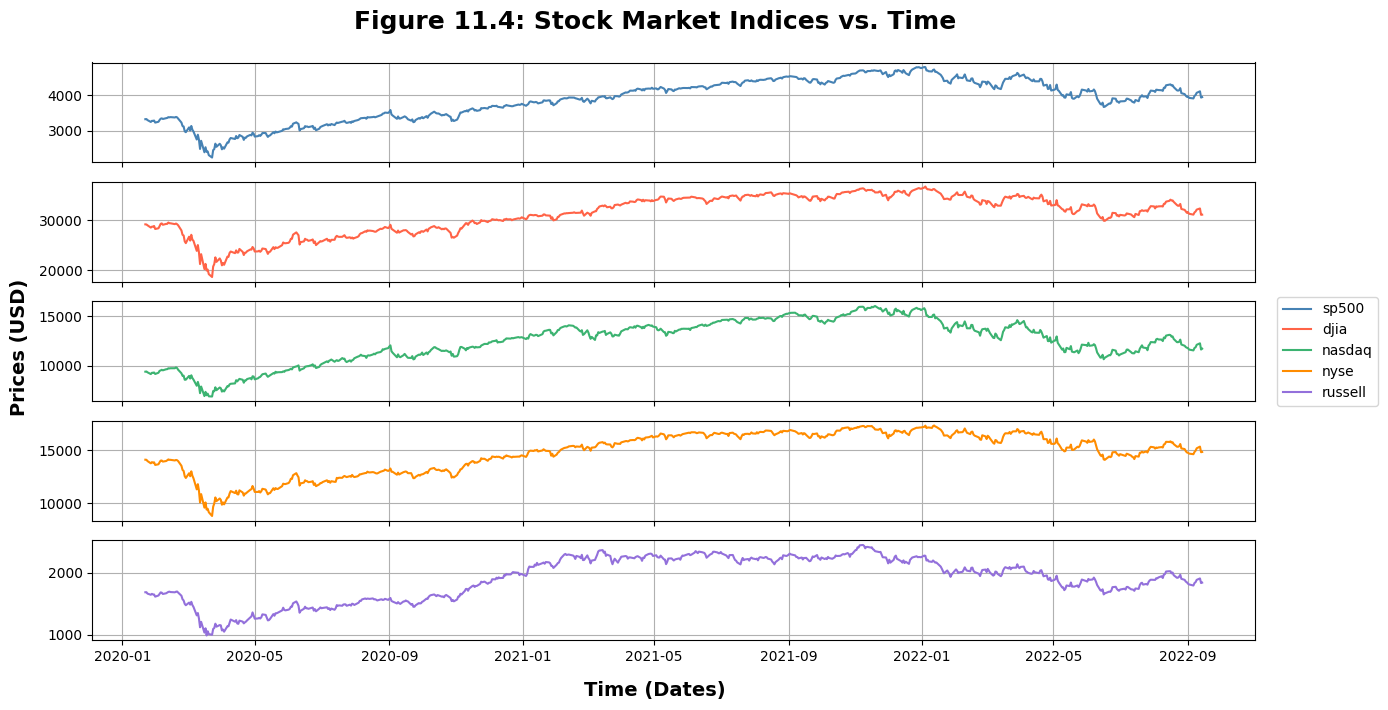

In [117]:
title = 'Figure 11.4: Stock Market Indices vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.112, 2.9)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (USD)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(stk_mkt_idxs_df, title)

### **11.5: Load Stock Market Indices**

In [118]:
stk_mkt_idxs_df.to_json(assetx.config_dict['file']['stk_mkt'], mode = 'w')

## <br> **Section 12: Stock Market Indices (%)**

### **12.1: Calculate Stock Market Indices (%)**

In [119]:
sp500_pcs_pct_series   = dtypesx.cnv_to_pct_chg(sp500_pcs_series)

logx.log_write_obj(sp500_pcs_pct_series)

In [120]:
djia_pcs_pct_series    = dtypesx.cnv_to_pct_chg(djia_pcs_series)

logx.log_write_obj(djia_pcs_pct_series)

In [121]:
nasdaq_pcs_pct_series  = dtypesx.cnv_to_pct_chg(nasdaq_pcs_series)

logx.log_write_obj(nasdaq_pcs_pct_series)

In [122]:
nyse_pcs_pct_series    = dtypesx.cnv_to_pct_chg(nyse_pcs_series)

logx.log_write_obj(nyse_pcs_pct_series)

In [123]:
russell_pcs_pct_series = dtypesx.cnv_to_pct_chg(russell_pcs_series)

logx.log_write_obj(russell_pcs_pct_series)

### **12.2: Transform Stock Market Indices (%)**

In [124]:
ttl_dict \
    = {'sp500%':   sp500_pcs_pct_series,
       'djia%':    djia_pcs_pct_series,
       'nasdaq%':  nasdaq_pcs_pct_series,
       'nyse%':    nyse_pcs_pct_series,
       'russell%': russell_pcs_pct_series}

stk_mkt_idxs_pct_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(stk_mkt_idxs_pct_df)

In [125]:
title = 'Table 12.2: Stock Market Indices (%)'

fmt_dict \
    = {'sp500%':   pandasx.fmt_dict['pct_flt'],
       'djia%':    pandasx.fmt_dict['pct_flt'],
       'nasdaq%':  pandasx.fmt_dict['pct_flt'],
       'nyse%':    pandasx.fmt_dict['pct_flt'],
       'russell%': pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(stk_mkt_idxs_pct_df, title, hide_idx_bool = False).format(fmt_dict)

,sp500%,djia%,nasdaq%,nyse%,russell%
2020-01-23,0.11%,-0.09%,0.20%,-0.06%,0.03%
2020-01-24,-0.90%,-0.58%,-0.93%,-0.88%,-1.35%
2020-01-27,-1.57%,-1.57%,-1.89%,-1.49%,-1.09%
2020-01-28,1.01%,0.66%,1.43%,0.78%,0.86%
2020-01-29,-0.09%,0.04%,0.06%,-0.24%,-0.55%
2020-01-30,0.31%,0.43%,0.26%,0.13%,-0.06%
2020-01-31,-1.77%,-2.09%,-1.59%,-1.79%,-2.07%
2020-02-03,0.73%,0.51%,1.34%,0.47%,1.12%
2020-02-04,1.50%,1.44%,2.10%,1.35%,1.50%
2020-02-05,1.13%,1.68%,0.43%,1.17%,1.52%


### **12.3: Correlation (Spearman): Stock Market Indices (%)**

In [126]:
title = 'Table 12.3: Correlation (Spearman): Stock Market Indices (%)'

pandasx.rtn_fmt_tbl(stk_mkt_idxs_pct_df.corr(method = 'spearman'), title, hide_idx_bool = False)

,sp500%,djia%,nasdaq%,nyse%,russell%
sp500%,1.00,0.93,0.92,0.92,0.84
djia%,0.93,1.00,0.77,0.94,0.83
nasdaq%,0.92,0.77,1.00,0.77,0.78
nyse%,0.92,0.94,0.77,1.00,0.89
russell%,0.84,0.83,0.78,0.89,1.00


### **12.4: Display Stock Market Indices (%)**

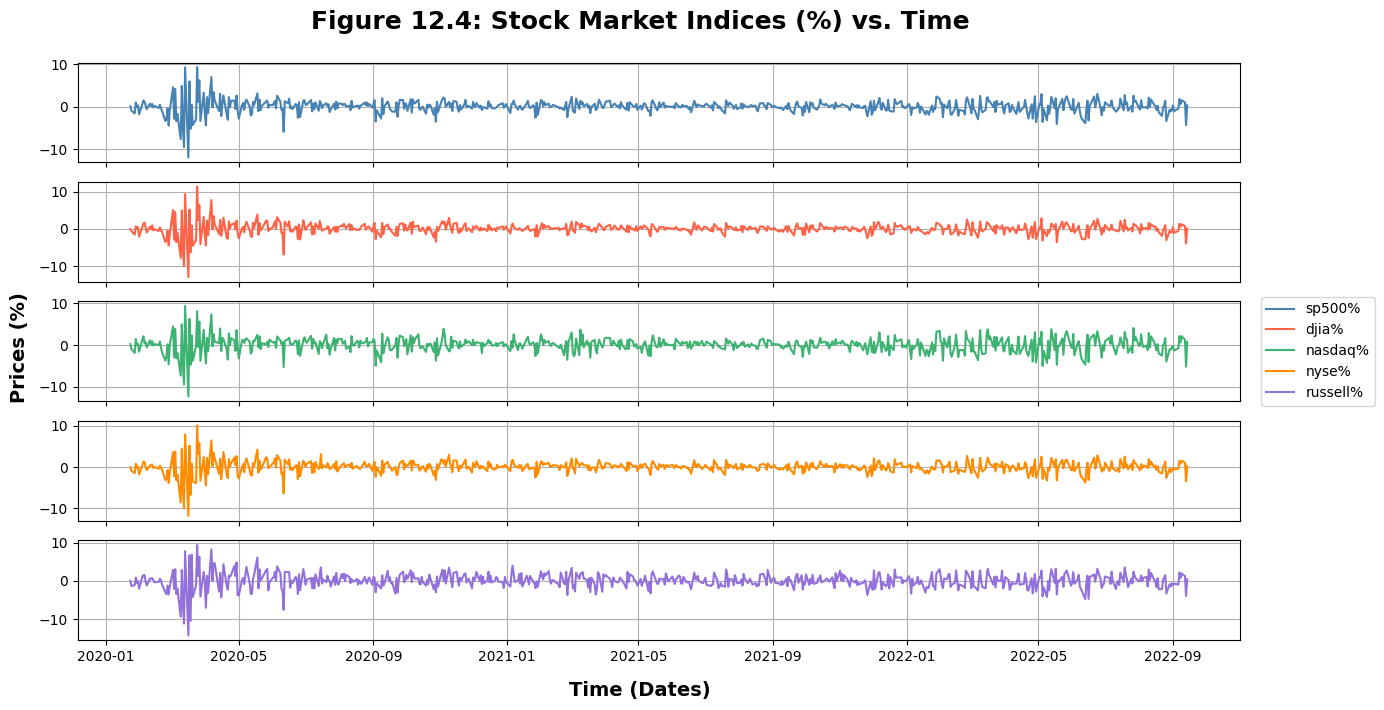

In [127]:
title = 'Figure 12.4: Stock Market Indices (%) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.122, 2.9)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices (%)')

matplotlibx.set_line_multichart_fig_dims(15.0, 7.5)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.03)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(stk_mkt_idxs_pct_df, title)

## <br> **Section 13: COVID-19 Data (USA)**

### **13.1: Extract COVID-19 Data (USA)**

In [128]:
usa_covid_df \
    = assetx.rtn_covid_cntry_file_df \
        (assetx.config_dict['file']['covid_usa'], 'US', sp500_pcs_series)

logx.log_write_obj(usa_covid_df)

In [129]:
title = 'Table 13.1: COVID-19 Data (USA)'

pandasx.rtn_fmt_tbl(usa_covid_df[150:160], title, hide_idx_bool = False)

,covid_cases,covid_deaths,covid_c&d,cml_covid_cases,cml_covid_deaths,cml_covid_c&d
2020-08-25,"40,696",885,"41,581","5,617,705","161,989","5,779,694"
2020-08-26,"46,970","1,057","48,027","5,664,675","163,046","5,827,721"
2020-08-27,"46,790",954,"47,744","5,711,465","164,000","5,875,465"
2020-08-28,"46,689","1,031","47,720","5,758,154","165,031","5,923,185"
2020-08-31,"39,130",581,"39,711","5,874,328","167,154","6,041,482"
2020-09-01,"39,014",852,"39,866","5,913,342","168,006","6,081,348"
2020-09-02,"41,978",875,"42,853","5,957,025","168,881","6,125,906"
2020-09-03,"45,147",951,"46,098","6,002,172","169,832","6,172,004"
2020-09-04,"50,962",922,"51,884","6,053,134","170,754","6,223,888"
2020-09-08,"28,436",570,"29,006","6,181,114","173,216","6,354,330"


### **13.2: Correlation (Pearson): COVID-19 Data (USA)**

In [130]:
title = 'Table 13.2: Correlation (Pearson): COVID-19 Data (USA)'

pandasx.rtn_fmt_tbl(usa_covid_df.corr(method = 'pearson'), title, hide_idx_bool = False)

,covid_cases,covid_deaths,covid_c&d,cml_covid_cases,cml_covid_deaths,cml_covid_c&d
covid_cases,1.00,0.49,1.00,0.31,0.32,0.31
covid_deaths,0.49,1.00,0.50,0.00,0.05,0.00
covid_c&d,1.00,0.50,1.00,0.31,0.32,0.31
cml_covid_cases,0.31,0.00,0.31,1.00,0.97,1.00
cml_covid_deaths,0.32,0.05,0.32,0.97,1.00,0.98
cml_covid_c&d,0.31,0.00,0.31,1.00,0.98,1.00


### **13.3: Display COVID-19 Data (USA)**

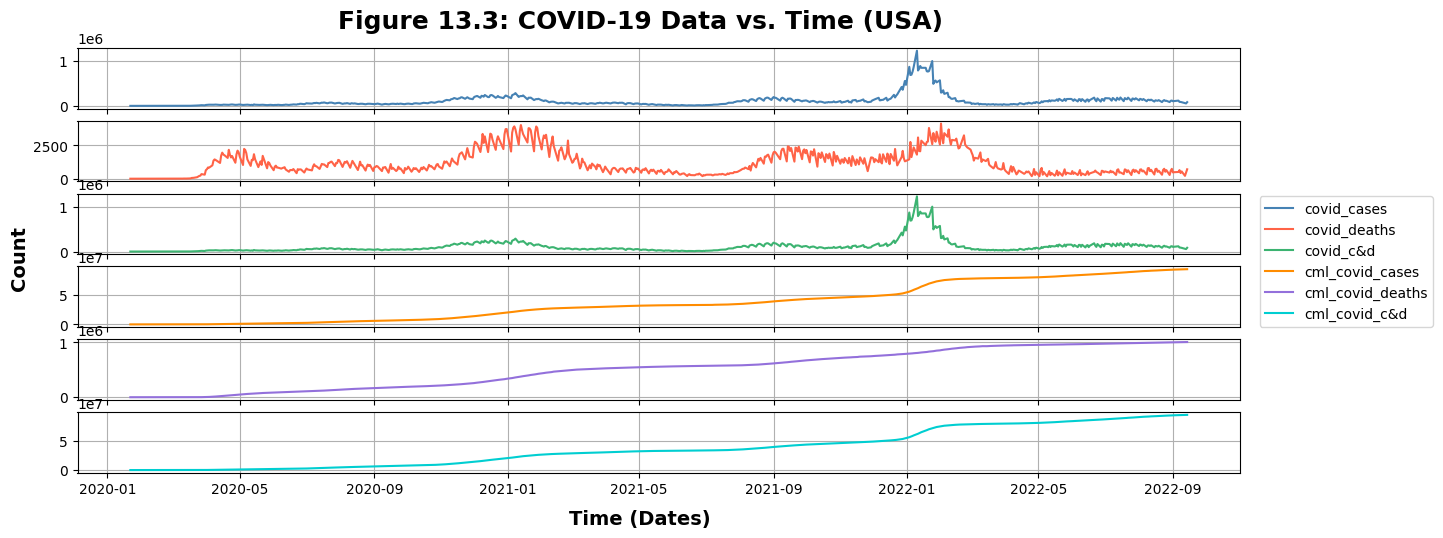

In [131]:
title = 'Figure 13.3: COVID-19 Data vs. Time (USA)'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.172, 3.48)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Count')

matplotlibx.set_line_multichart_fig_dims(15.0, 5.5181)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(usa_covid_df, title)

### **13.4: Load COVID-19 Data (USA)**

In [132]:
usa_covid_df.to_json(assetx.config_dict['file']['covid_usa'], mode = 'w')

## <br> **Section 14: COVID-19 Data (USA) (%)**

### **14.1: Calculate COVID-19 Data (USA) (%)**

In [133]:
covid_cases_pct_series        = dtypesx.cnv_to_pct_chg(usa_covid_df['covid_cases'])

logx.log_write_obj(covid_cases_pct_series)

In [134]:
covid_deaths_pct_series       = dtypesx.cnv_to_pct_chg(usa_covid_df['covid_deaths'])

logx.log_write_obj(covid_deaths_pct_series)

In [135]:
covid_combined_pct_series     = dtypesx.cnv_to_pct_chg(usa_covid_df['covid_c&d'])

logx.log_write_obj(covid_combined_pct_series)

In [136]:
cml_covid_cases_pct_series    = dtypesx.cnv_to_pct_chg(usa_covid_df['cml_covid_cases'])

logx.log_write_obj(cml_covid_cases_pct_series)

In [137]:
cml_covid_deaths_pct_series   = dtypesx.cnv_to_pct_chg(usa_covid_df['cml_covid_deaths'])

logx.log_write_obj(cml_covid_deaths_pct_series)

In [138]:
cml_covid_combined_pct_series = dtypesx.cnv_to_pct_chg(usa_covid_df['cml_covid_c&d'])

logx.log_write_obj(cml_covid_combined_pct_series)

### **14.2: Transform COVID-19 Data (USA) (%)**

In [139]:
ttl_dict \
    = {'covid_cases%':      covid_cases_pct_series,
       'covid_deaths%':     covid_deaths_pct_series,
       'covid_c&d%':        covid_combined_pct_series,
       'cml_covid_cases%':  cml_covid_cases_pct_series,
       'cml_covid_deaths%': cml_covid_deaths_pct_series,
       'cml_covid_c&d%':    cml_covid_combined_pct_series}

usa_covid_pct_df = pd.DataFrame(ttl_dict).dropna()

logx.log_write_obj(usa_covid_pct_df)

In [140]:
title = 'Table 14.2: COVID-19 Data (USA) (%)'

fmt_dict \
    = {'covid_cases%':      pandasx.fmt_dict['pct_flt'],
       'covid_deaths%':     pandasx.fmt_dict['pct_flt'],
       'covid_c&d%':        pandasx.fmt_dict['pct_flt'],
       'cml_covid_cases%':  pandasx.fmt_dict['pct_flt'],
       'cml_covid_deaths%': pandasx.fmt_dict['pct_flt'],
       'cml_covid_c&d%':    pandasx.fmt_dict['pct_flt']}

pandasx.rtn_fmt_tbl(usa_covid_pct_df[50:60], title, hide_idx_bool = False).format(fmt_dict)

,covid_cases%,covid_deaths%,covid_c&d%,cml_covid_cases%,cml_covid_deaths%,cml_covid_c&d%
2020-04-03,7.38%,-1.78%,7.07%,12.77%,17.35%,12.88%
2020-04-06,-6.27%,21.31%,-5.42%,31.29%,55.33%,31.86%
2020-04-07,2.94%,34.93%,4.19%,8.32%,15.58%,8.53%
2020-04-08,9.56%,6.80%,9.42%,8.42%,14.40%,8.60%
2020-04-09,3.20%,-2.98%,2.89%,8.01%,12.21%,8.14%
2020-04-13,-26.21%,-15.70%,-25.72%,25.26%,40.73%,25.76%
2020-04-14,4.76%,46.32%,6.96%,4.58%,9.54%,4.76%
2020-04-15,-1.41%,12.96%,-0.36%,4.32%,9.84%,4.53%
2020-04-16,25.98%,-7.43%,23.23%,5.21%,8.29%,5.33%
2020-04-17,-4.17%,-2.66%,-4.08%,4.75%,7.45%,4.86%


### **14.3: Correlation (Pearson): COVID-19 Data (USA) (%)**

In [141]:
title = 'Table 14.3: Correlation (Pearson): COVID-19 Data (USA) (%)'

pandasx.rtn_fmt_tbl(usa_covid_pct_df.corr(method = 'pearson'), title, hide_idx_bool = False)

,covid_cases%,covid_deaths%,covid_c&d%,cml_covid_cases%,cml_covid_deaths%,cml_covid_c&d%
covid_cases%,1.00,0.25,1.00,0.45,0.64,0.46
covid_deaths%,0.25,1.00,0.23,0.07,0.03,0.07
covid_c&d%,1.00,0.23,1.00,0.44,0.70,0.46
cml_covid_cases%,0.45,0.07,0.44,1.00,0.48,1.00
cml_covid_deaths%,0.64,0.03,0.70,0.48,1.00,0.51
cml_covid_c&d%,0.46,0.07,0.46,1.00,0.51,1.00


### **14.4: Display COVID-19 Data (USA) (%)**

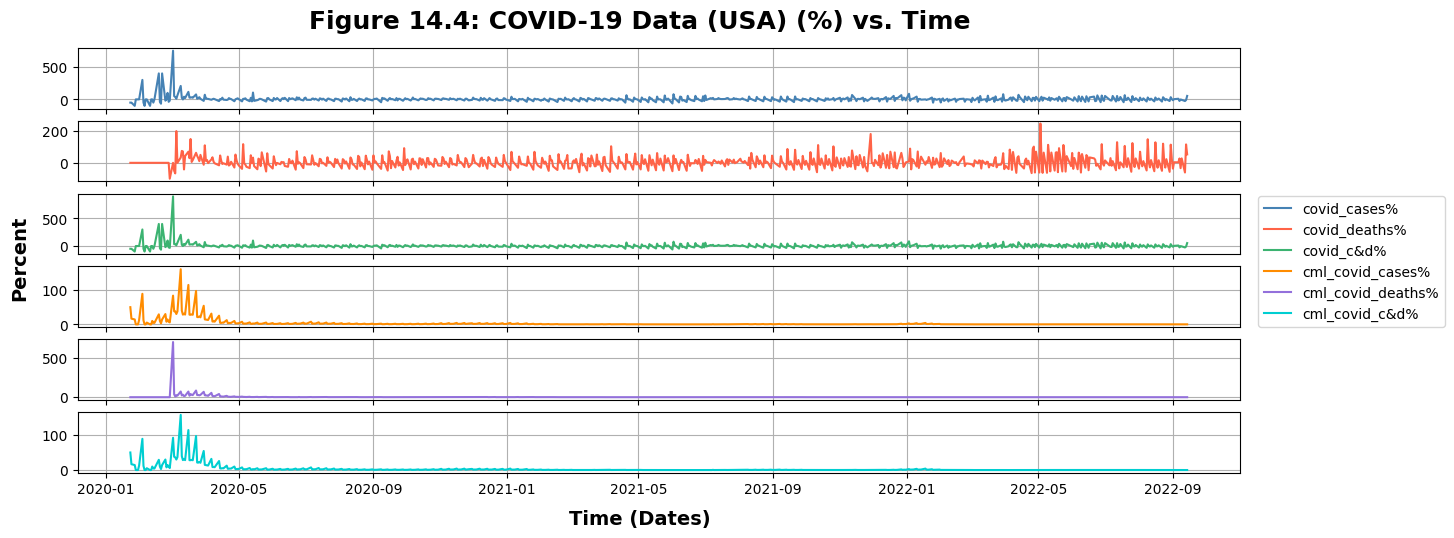

In [142]:
title = 'Figure 14.4: COVID-19 Data (USA) (%) vs. Time'


matplotlibx.set_line_chart_legend_bbox_to_anchor(1.182, 3.48)

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Percent')

matplotlibx.set_line_multichart_fig_dims(15.0, 5.5181)

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.08, 0.5)


matplotlibx.line_multichart(usa_covid_pct_df, title)

## <br> **Section 15: Oil & Gas Energy Sector Company Data**

### **15.1: Extract, Transform, and Load All Stock Symbols from SEC**

In [143]:
stock_array = assetx.rtn_all_symbols_file_array(assetx.config_dict['file']['all_stcks'])

logx.log_write_obj(stock_array)

In [144]:
logx.print_and_log_text \
    ('\033[1m' \
        + 'There are {:,} stock symbols from the SEC.' \
            .format(len(stock_array)) \
        + '\033[0m')

There are 9,642 stock symbols from the SEC.


### **15.2: Extract, Transform, and Load All Oil & Gas Energy Sector Stock Symbols**

In [145]:
sctr_array \
    = assetx.rtn_sector_symbols_file_array \
        (stock_array,
         assetx.config_dict['file']['srch'],
         assetx.config_dict['file']['sctr_stcks'])

logx.log_write_obj(sctr_array)

In [146]:
logx.print_and_log_text \
    ('\033[1m' \
        + 'There are {:,} oil & gas energy sector stock symbols.' \
            .format(len(sctr_array)) \
        + '\033[0m')

There are 218 oil & gas energy sector stock symbols.


### **15.3: Extract, Transform, and Load Oil & Gas Energy Sector Company Data**

In [147]:
oil_cmps_df \
    = assetx.rtn_cmps_info_file_df \
        (sctr_array, assetx.config_dict['file']['cmps'])
  
logx.log_write_obj(oil_cmps_df)

In [148]:
logx.print_and_log_text \
    ('\033[1m' \
     + 'There are {:,} '.format(oil_cmps_df['symbol'].count()) \
     + 'oil companies with the requisite information.\n' \
     + '\033[0m')

There are 218 oil companies with the requisite information.



### **15.4: Display Oil & Gas Energy Sector Company Data**

In [149]:
title = 'Table 15.4: U.S. Oil Energy Sector Companies'

fmt_dict \
    = {'longitude':         pandasx.fmt_dict['flt'],
       'latitude':          pandasx.fmt_dict['flt'],
       'min_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'max_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'mean_market_cap':   pandasx.fmt_dict['curr_flt_int'],
       'median_market_cap': pandasx.fmt_dict['curr_flt_int'],
       'std_market_cap':    pandasx.fmt_dict['curr_flt_int'],
       'sem_market_cap':    pandasx.fmt_dict['curr_flt_int']}

pandasx.rtn_fmt_tbl(oil_cmps_df, title).format(fmt_dict)

symbol,company_name,industry,address,longitude,latitude,min_market_cap,max_market_cap,mean_market_cap,median_market_cap,std_market_cap,sem_market_cap
ALTX,"altex industries, inc.",oil & gas e&p,"700 colorado boulevard, denver, co 80206-4084, united states",-104.94,39.73,"$840,798","$2,428,280","$1,252,837","$1,096,686","$349,013","$13,504"
AM,antero midstream corporation,oil & gas midstream,"1615 wynkoop street, denver, co 80202, united states",-105.00,39.75,"$937,650,764","$5,577,246,720","$3,951,934,011","$4,383,486,720","$1,141,576,220","$44,168,910"
AMPY,amplify energy corp.,oil & gas e&p,"500 dallas street, houston, tx 77002, united states",-95.37,29.76,"$19,534,112","$382,097,672","$133,330,082","$123,528,666","$86,200,019","$3,335,179"
APA,apa corporation,oil & gas e&p,"2000 w. sam houston pkwy. s., houston, tx 77042-3643, united states",-95.56,29.75,"$1,517,220,296","$17,420,489,718","$8,304,335,055","$7,737,609,152","$3,539,638,220","$136,952,714"
AR,antero resources corporation,oil & gas e&p,"1615 wynkoop street, denver, co 80202, united states",-105.00,39.75,"$179,821,300","$15,290,790,567","$4,532,050,987","$3,737,865,087","$3,925,945,093","$151,899,376"
AROC,"archrock, inc.",oil & gas equipment & services,"9807 katy freeway, houston, tx 77024, united states",-95.54,29.78,"$321,027,000","$1,697,901,368","$1,224,075,604","$1,284,275,176","$259,413,987","$10,037,029"
BATL,battalion oil corporation,oil & gas e&p,"820 gessner road, houston, tx 77024, united states",-95.54,29.78,"$36,459,000","$344,518,463","$176,685,352","$171,034,448","$62,076,221","$2,401,801"
BDCO,blue dolphin energy company,oil & gas refining & marketing,"801 travis street, houston, tx 77002, united states",-95.36,29.76,"$1,650,155","$34,777,650","$7,696,172","$5,917,152","$5,735,990","$221,932"
BIREF,birchcliff energy ltd.,oil & gas e&p,"600 - 3rd avenue s.w., calgary, ab t2p 0g5, canada",-114.07,51.05,"$112,863,233","$2,615,772,751","$964,018,524","$749,713,940","$675,994,122","$26,154,998"
BKR,baker hughes company,oil & gas equipment & services,"575 north dairy ashford road, houston, tx 77079-1121, united states",-95.61,29.77,"$9,620,815,951","$40,683,350,385","$22,622,425,812","$22,113,702,000","$6,906,749,101","$267,230,146"


### **15.4: Load Oil & Gas Energy Sector Company Data**

In [150]:
oil_cmps_df.to_json(assetx.config_dict['file']['cmps'], mode = 'w')

In [151]:
logx.end_program()